# 5장 — 텍스트에서 지식 그래프를 만들기

| | |
| --- | --- |
| **책** | Alessandro Negro 외, *Knowledge Graphs and LLMs in Action* (Manning) **5장** — Extracting domain-specific knowledge from unstructured data |
| **해설 원본** | [05_..._ko_explained.md 열기](../../05_extracting_domain_specific_knowledge_from_unstructured_data_ko_explained.md) |
| **원서 원문** | [05_....md 열기](../../05_extracting_domain_specific_knowledge_from_unstructured_data.md) |
| **이 폴더** | [listings/](./listings) · [requirements.txt](./requirements.txt) |
| **원서 저장소** | [alenegro81/.../chapters/ch07 열기](https://github.com/alenegro81/knowledge-graphs-and-llms-in-action/tree/main/chapters/ch07) |
| **리스팅 번호** | **단일 오프셋으로 표현되지 않는다.** 저장소 파일명이 책 번호보다 한 칸 크고(`listing_2.py` = 책 5.1), 출력 예시 자리에는 파일이 아예 없다(`listing_4`·`listing_6`·`listing_8` 결번). 그래서 `study.toml` 의 `[mapping.listings.ch05]` 이 `path` 로 직접 가리킨다 — 아래 헬퍼 셀이 그 대조표를 출력한다 |
| **외부 서비스** | **OpenAI 호환 엔드포인트 하나뿐.** Neo4j·도커·내려받을 데이터셋이 없고, 엔드포인트가 없어도 이 노트북은 끝까지 실행된다 |

---

3\~4장은 **이미 구조를 가진 것** 에서 그래프를 세웠다. 온톨로지에서 스키마를 뽑고([3장](../../../chapter_03_create_your_first_knowledge_graph_from_ontologies/src/ch03/03_chapter_guide.ipynb)), 표로 배포되는 공개 데이터셋 여러 개를 이어 붙였다([4장](../../../chapter_04_from_simple_networks_to_multisource_integration/src/ch04/04_chapter_guide.ipynb)). 5장에서 입력이 처음으로 **줄글** 이 된다. 원본은 1930년대 록펠러 재단의 프로그램 담당관 **워런 위버(Warren Weaver)** 가 회의·전화·저녁 식사 자리에서 들은 것을 타자기로 급히 친 일기다. 축약과 이니셜과 분야 전문 용어로 가득한 그 글에서 사람·조직·연구 주제와 그들 사이의 관계를 뽑아내는 것이 이 장의 과제이고, 그렇게 뽑은 것으로 실제 그래프를 만드는 일은 [6장](../../../chapter_06_building_knowledge_graphs_with_large_language_models/src/ch06/06_chapter_guide.ipynb)이 이어받는다.

그래서 이 장은 **코드가 적다.** 책 리스팅 일곱 개 중 **셋(5.3·5.5·5.7)은 코드가 아니라 GPT 출력 예시** 이고, 나머지 넷 중 셋(5.1·5.4·5.6)은 파이썬 문법을 빌렸을 뿐 실질은 **프롬프트 문자열 세 덩어리** 다. 실행할 코드다운 코드는 API 호출 하나(5.2)뿐이다. 그 대신 이 장이 세 번 반복하는 것이 있다 — **같은 문단을 같은 모델에 넣고 프롬프트만 고쳐 쓰면서 무엇이 왜 나아지는가** 를 보는 일이다. 그것이 이 노트북의 무게중심이다.

| 절 | 내용 | 이 절이 답하는 질문 | 리스팅 |
| --- | --- | --- | --- |
| 5.1 | 아카이브라는 도전 — 역사 기록의 산을 마주하기 | 왜 이 데이터인가. 무엇을 알아내려 하나 | — |
| 5.2 | 지식 추출의 핵심 개념 — 개체와 관계, 두 개의 기둥 | 텍스트에서 그래프로 가려면 무엇을 뽑아야 하나 | — |
| 5.2.1 | 개체명 인식하기 — 글 속 주인공 찾아내기 | 일반 NER 로는 왜 부족한가 | — |
| 5.2.2 | 관계 추출하기 — 개체들을 이어 주는 실 | 점을 선으로 잇는 일은 무엇인가 | — |
| 5.3 | 대규모 언어 모델로 지식 그래프 만들기 — 판을 바꾸는 도구 | LLM 은 이 문제의 무엇을 바꾸나 | — |
| 5.3.1 | LLM 활용하기 — 그냥 쓸까, 길들여 쓸까 | 프롬프트인가 파인튜닝인가 | — |
| 5.3.2 | 프롬프트 엔지니어링 예시 — 프롬프트를 진화시켜 가기 | 프롬프트를 고치면 출력의 무엇이 달라지나 | **5.1\~5.7** |
| 5.3.3 | 프롬프트 엔지니어링 지침 — 오래도록 통하는 원칙들 | 모델이 바뀌어도 남는 원칙은 무엇인가 | — |
| 5.3.4 | 지식 그래프 구축: 전통적 NLP인가, LLM인가? | 무엇을 기준으로 고르나 | — |
| — | 요약 | | |

> **한 문장 요약** — LLM 은 개체명 인식·관계 추출·상호참조 해소를 **한 번의 호출로** 처리해 전통 NLP 파이프라인의 초기 투자를 없애 주지만, "모든 개체와 관계를 찾아라" 식의 두루뭉술한 프롬프트는 같은 개념에 제각각인 이름을 붙여(실측 **관계 유형 19\~22종 · 엔티티 유형 12\~17종**) 지식 그래프 스키마로 쓸 수 없는 결과를 낸다 — 프롬프트에 **관심 있는 개체·관계 목록을 열거** 하는 것만으로 그 수가 **4\~7종 · 3\~4종** 으로 접히고, 예시를 복잡하게 만들면 잃었던 관계(`student of`·`works for`)까지 되살아난다.

### 이 노트북이 재현하는 것과 재현하지 않는 것

책은 `gpt-4o-mini` 로 실험했고, 지금 이 저장소가 쓰는 로컬 프록시에는 **그 모델이 없다.** 이것은 책의 오류가 아니라 **version-drift**(집필 시점과 지금의 모델이 다른 것)다. 저자들도 5.3.2 절 끝에서 같은 예고를 남겼다 — 새 모델이 나올 것이므로 특정 모델의 세부보다 근본 원리에 초점을 맞추라고. 그래서 이 노트북의 재현 목표를 이렇게 나눈다.

| 재현 대상 | 재현되는가 | 근거 |
| --- | --- | --- |
| 책 5.3·5.5·5.7 의 **글자 그대로의 출력** | ❌ | 모델이 다르다. 게다가 `temperature=0` 이어도 같은 모델이 실행마다 다른 답을 낸다 (아래 실측) |
| **관계 유형·엔티티 유형이 v1 에서 흩어지고 v2 에서 정규화되는 현상** | ✅ | 2026-07-25 실측에서 관계 유형 19\~22종 → 4\~7종. 이 장의 논지 그 자체다 |
| v3 이 잃었던 관계(`student of`·`works for`)를 되살리는 것 | ✅ | 실측에서 v3 이 두 관계를 모두 복원했다 |
| 프롬프트 **원문 세 판본의 차이** | ✅ | 저장소 파일이 있으므로 완전히 결정적이다. 이 노트북이 `difflib` 로 직접 보여 준다 |

> **왜 "책이 틀렸다"고 쓰지 않는가.** 모델이 달라 숫자가 달라진 것을 오류로 적으면 그 서술이 틀린 것이 된다. 이 교재에서 확인한 오류·불일치는 교재 루트의 [`errata.toml`](../../../errata.toml) 이 정본이고, 거기서도 이런 항목은 `status = "version-drift"` 로 따로 표시한다. 이 장에서 **진짜 결함** 으로 확인된 것은 뒤의 5.3.2 절에서 따로 다룬다 (책 5.6 의 task 설명이 저장소 코드와 다르다).

---
## 실행 환경 — 5장은 데이터베이스가 없다

**외부 서비스가 사실상 하나뿐이다.** Neo4j 도, 도커 컨테이너도, 내려받을 데이터셋도 없다. 근거는 세 가지다.

| 근거 | 확인 방법 |
| --- | --- |
| 이 장은 그래프를 **만들지 않는다** | 5장의 산출물은 "관계 목록"이라는 텍스트다. 그것을 실제 노드·관계로 적재하는 일은 6장([`ch06`](../../../chapter_06_building_knowledge_graphs_with_large_language_models/src/ch06))의 임포터가 한다 |
| 저장소 코드가 드라이버를 임포트하지 않는다 | [`listings/`](./listings) 의 다섯 파일 어디에도 `neo4j` 가 없다. `openai`·`dotenv`·`requests` 셋뿐이다 |
| 데이터가 코드 안에 있다 | 처리할 일기 토막은 [`listings/listing_3.py`](./listings/listing_3.py) 의 `__main__` 블록에 문자열로 박혀 있다. `data-manifest.toml` 항목이 없다 |

남는 하나가 **OpenAI 호환 엔드포인트** 인데, 그것도 **없어도 이 노트북은 끝까지 실행된다.** 아래 `RUN_LLM` 이 기본값 `False` 이고, 그때는 2026-07-25 에 실제로 측정해 노트북 안에 보존해 둔 응답으로 같은 분석을 돌린다.

### 커널과 패키지

교재 루트의 `.venv`(Python 3.10) 커널에서 돌아간다. 처음이면 교재 루트에서 [`setup_env.py`](../../../setup_env.py) 를 한 번 실행한다.

```bash
python3 setup_env.py
```

이 챕터에는 `requirements.lock` 이 **없다.** [`requirements.txt`](./requirements.txt) 가 pin 한 셋이 전부다.

| 패키지 | `requirements.txt` | 이 저장소 `.venv` | 쓰는 곳 |
| --- | --- | --- | --- |
| `openai` | `1.69.0` | `1.69.0` — 일치 | 책 5.2 의 `client.chat.completions.create()` |
| `dotenv` | `0.9.9` | `0.9.9` (+ `python-dotenv 1.2.2`) | `listing_3.py` 의 `load_dotenv()`. `.env` 가 없어도 조용히 `False` 를 돌려주므로 실패하지 않는다 |
| `requests` | `2.32.3` | `2.34.2` — 상위 | `listing_1.py`(UBIAI) 전용. **책에 없는 리스팅** 이라 이 노트북은 쓰지 않는다 |

> `requests` 를 `2.32.3` 으로 되돌리지 마라. 13장([`ch13`](../../../chapter_13_knowledge_graph_powered_retrieval_augmented_generation/src/ch13)) 의 LangChain 이 상위 버전을 끌어왔고, 이 챕터는 `requests` 를 실제로 쓰지 않으므로 차이가 영향을 주지 않는다. 업스트림 pin 은 **출처 기록** 이고 재현 기준은 노트북이 적는 실제 검증 버전이다.

### LLM 엔드포인트 — 켤 때만 필요하다

`study.toml` 의 `[llm].env_file` 은 **저장소 밖** 파일을 가리킨다. 비밀값을 이 저장소에 복사하지 않기 위한 구조다. `studykit.llm.configure()` 가 교재 코드마다 다르게 쓰는 `OPENAI_KEY` 와 `OPENAI_API_KEY` 를 양쪽 다 채우고, `OPENAI_BASE_URL` 도 함께 넣는다 (OpenAI SDK 가 이 변수를 자동으로 읽으므로, `base_url` 을 넘기지 않는 책 코드도 그대로 프록시로 간다).

| 항목 | 값 |
| --- | --- |
| 책이 쓰는 모델 | `gpt-4o-mini` (프록시에 **없다** — version-drift) |
| 이 노트북이 쓰는 모델 | `gpt-5.4-mini` (`LLM_MODEL` 로 바꿀 수 있다) |
| 모델 상수를 바꾸는 방법 | `llm.override_module_model(listing_3)` — **업스트림 파일은 고치지 않고** 임포트된 모듈의 `OPENAI_MODEL` 만 런타임에 교체한다 |
| 기본값 | `RUN_LLM = False` — 저장소를 새로 클론한 사람에게는 `[llm].env_file` 이 없으므로 |

### 실행 시간 감각

| 셀 | 하는 일 | 실측 |
| --- | --- | --- |
| 환경 점검 | 임포트 확인 (+ `RUN_LLM = True` 면 엔드포인트 모델 목록 조회) | 1초 미만 (+ 1\~2초) |
| 리스팅 헬퍼 | 대조표 출력 | 1초 미만 |
| 프롬프트 v1 · v2 · v3 셀 | 원문 출력 · `difflib` 비교 · 보존된 실측 집계 | 각 1초 미만 |
| 같은 셀, `RUN_LLM = True` 일 때 | API 호출 한 번씩 | **16.0\~83.8초** (아래 참고) |

**`RUN_LLM = False` 면 노트북 전체가 5초 안에 끝난다.** `True` 로 켜면 호출 세 번에 1분 30초에서 3분까지 걸린다.

> **⚠️ 프록시가 간헐적으로 503 을 낸다.** 2026-07-25 측정 중 두 번 발생했다 — `auth_unavailable: no auth available` 과 `biscuit_baker_service_me_circuit_open` 이다. 둘 다 몇 분 뒤 스스로 복구됐다. 그래서 아래 LLM 호출 함수는 예외를 잡아 **빈 문자열을 돌려주고 계속 진행한다.** 한 번의 503 으로 Run All 이 끊기지 않게 하기 위한 것이다.

In [1]:
"""환경 점검 — 이 셀이 통과하면 이후 모든 셀을 돌릴 수 있다.

5장은 그래프를 만들지 않는다. 데이터베이스도 데이터셋도 없으므로 확인할 것은 셋뿐이다.

  1) cwd 가 이 챕터 폴더인가 (listings/ 존재로 판정)
  2) requirements.txt 의 세 패키지가 임포트되는가
  3) (선택) OpenAI 호환 엔드포인트가 살아 있는가

3) 이 실패해도 이 노트북은 끝까지 실행된다. RUN_LLM 이 False 로 내려가고, 프롬프트
원문 비교와 보존된 실측 집계는 그대로 진행된다. 이 장의 논지는 특정 응답의 글자가
아니라 **프롬프트 세 판본이 출력의 분포를 어떻게 바꾸는가** 에 있기 때문이다.

Neo4j 연결 검사는 일부러 넣지 않았다. 없어도 되는 인프라를 있어야 하는 것처럼 만들면
스터디원이 이 장에서 막힌다.
"""
import importlib
import importlib.metadata as metadata
import platform
import sys
from pathlib import Path

from studykit import config, llm

STUDY = config.load()     # 위로 올라가며 study.toml 을 찾는다
HERE = Path.cwd()         # 주피터는 노트북 폴더를 cwd 로 둔다
REPO_DIR = "ch05"         # 소스 폴더 = 책 장 번호 (업스트림 MEAP 에서는 ch07)
UPSTREAM_DIR = STUDY.upstream_dirs[REPO_DIR]   # "ch07" — study.toml 이 정본이다

# ── 이 노트북의 스위치 ────────────────────────────────────────────────────────
# True 로 두면 프롬프트 v1·v2·v3 를 각각 한 번씩 실제 엔드포인트에 던진다.
# 기본값이 False 인 이유: study.toml 의 [llm].env_file 이 저장소 밖 파일을 가리키므로
# 저장소를 새로 클론한 사람에게는 그 파일이 없다. 그때도 노트북은 완주해야 한다.
RUN_LLM = False
# 책은 "gpt-4o-mini" 를 쓴다. 지금 프록시에 그 모델이 없어 대체한다 (version-drift).
LLM_MODEL = "gpt-5.4-mini"

assert (HERE / "listings").is_dir(), f"cwd 가 챕터 폴더가 아니다: {HERE}"

print("교재      :", STUDY.title)
print("파이썬    :", platform.python_version(), "(study.toml 고정:", STUDY.python + ")")
print("작업 폴더 :", HERE.name, " (책 5장 ↔ 업스트림", UPSTREAM_DIR + ")")

# ── 1) 패키지 ────────────────────────────────────────────────────────────────
# requirements.lock 이 없는 챕터다. requirements.txt 의 세 줄이 전부다.
# 'dotenv' 는 python-dotenv 를 끌어오는 얇은 shim 패키지라 모듈에 __version__ 이 없다.
# 그래서 모듈 속성이 아니라 배포판 메타데이터에서 버전을 읽는다.
REQUIRED = {
    # 배포판 이름: (임포트 이름, requirements.txt 의 pin, 쓰는 곳)
    "openai":   ("openai",   "1.69.0", "책 5.2 의 client.chat.completions.create()"),
    "dotenv":   ("dotenv",   "0.9.9",  "listing_3.py 의 load_dotenv() — .env 가 없어도 실패하지 않는다"),
    "requests": ("requests", "2.32.3", "listing_1.py(UBIAI) 전용. 책에 없는 리스팅이라 쓰지 않는다"),
}

missing = []
print(f"\n  {'패키지':<12}{'설치됨':<12}{'requirements.txt':<20}쓰는 곳")
for dist, (module_name, pinned, why) in REQUIRED.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        missing.append(dist)
        print(f"  ✗ {dist:<10}{'없음':<12}{pinned:<20}{why}")
        continue
    try:
        installed = metadata.version(dist)
    except metadata.PackageNotFoundError:
        installed = "?"
    mark = "일치" if installed == pinned else "다름"
    print(f"  ✓ {dist:<10}{installed:<12}{pinned + ' — ' + mark:<20}{why}")

if missing:
    raise RuntimeError(
        "패키지가 없다: " + ", ".join(missing)
        + "\n      이 챕터 폴더에서:  pip install -r requirements.txt"
    )

# listing_3.py 가 `from listing_2 import prompt_segments` 를 한다. 임포트가 되려면
# listings/ 가 sys.path 에 있어야 한다. 셀을 여러 번 돌려도 중복되지 않게 막는다.
LISTINGS = str(HERE / "listings")
if LISTINGS not in sys.path:
    sys.path.insert(0, LISTINGS)
print(f"\n  sys.path 에 listings/ 추가 — listing_3.py 가 listing_2 를 임포트한다")

# ── 2) OpenAI 호환 엔드포인트 (선택) ─────────────────────────────────────────
if RUN_LLM:
    try:
        llm.configure(STUDY, model=LLM_MODEL)
    except llm.LLMConfigError as exc:
        RUN_LLM = False
        print(f"\n  ⚠️ LLM 설정을 읽지 못했다 — {exc}")
        print("     RUN_LLM 을 False 로 내린다. 보존된 실측으로 계속 진행한다.")
    else:
        print("\n  LLM 설정:", llm.describe())         # 키는 마스킹된다
        try:
            models = llm.available_models()
        except Exception as exc:      # 프록시 중지·네트워크 단절. 실제로 겪은 상황이다
            RUN_LLM = False
            print(f"  ⚠️ 엔드포인트에 닿지 못했다 ({type(exc).__name__}: {exc})")
            print("     RUN_LLM 을 False 로 내린다. 보존된 실측으로 계속 진행한다.")
        else:
            print(f"  제공 모델 {len(models)}개: {', '.join(sorted(models))}")
            print(f"  책이 쓰는 gpt-4o-mini 제공 여부: {'gpt-4o-mini' in models}"
                  "  ← False 면 version-drift 다. 책이 틀린 것이 아니다")
            if LLM_MODEL not in models:
                RUN_LLM = False
                print(f"  ⚠️ '{LLM_MODEL}' 이 목록에 없다. 위 목록에서 골라 LLM_MODEL 을 바꿔라.")

# 아래 셀들이 실측값을 여기 모으고, 마지막 요약 셀이 그대로 인용한다.
MEASURED = {}

print()
if RUN_LLM:
    print(f"준비 완료 — 프롬프트 v1·v2·v3 를 '{LLM_MODEL}' 로 각각 한 번씩 호출한다.")
    print("            호출당 16.0~83.8초가 걸렸다. 프록시가 503 을 내면 그 판본만 건너뛴다.")
else:
    print("준비 완료 — API 호출 없이 진행한다.")
    print("            프롬프트 원문 비교와 2026-07-25 보존 실측 집계는 그대로 돌아간다.")

교재      : Knowledge Graphs and LLMs in Action
파이썬    : 3.10.18 (study.toml 고정: 3.10)
작업 폴더 : ch05  (책 5장 ↔ 업스트림 ch07)

  패키지         설치됨         requirements.txt    쓰는 곳
  ✓ openai    1.69.0      1.69.0 — 일치         책 5.2 의 client.chat.completions.create()
  ✓ dotenv    0.9.9       0.9.9 — 일치          listing_3.py 의 load_dotenv() — .env 가 없어도 실패하지 않는다


  ✓ requests  2.34.2      2.32.3 — 다름         listing_1.py(UBIAI) 전용. 책에 없는 리스팅이라 쓰지 않는다

  sys.path 에 listings/ 추가 — listing_3.py 가 listing_2 를 임포트한다

준비 완료 — API 호출 없이 진행한다.
            프롬프트 원문 비교와 2026-07-25 보존 실측 집계는 그대로 돌아간다.


In [2]:
"""리스팅 접근 헬퍼 — 위치의 정본은 study.toml 하나다.

이 챕터는 번호 대응이 두 겹으로 어긋난다.

  1) 저장소 파일명이 listing_1.py … listing_7.py 인데, listing_1.py(UBIAI 어노테이션
     API)가 최종 출간본에서 빠지면서 그 뒤가 한 칸씩 밀렸다.
         listing_2 = 책 5.1 · listing_3 = 책 5.2 · listing_5 = 책 5.4 · listing_7 = 책 5.6
  2) 책 5.3·5.5·5.7 은 코드가 아니라 **GPT 출력 예시** 라 대응 파일이 아예 없다.
     그래서 listing_4 · listing_6 · listing_8 이 결번이다.

그래서 [mapping.listing_offsets] 로는 표현되지 않는다 — 단일 오프셋이 존재하지 않는다.
study.toml 의 [mapping.listings.ch05] 이 path 로 직접 가리키고, 그 선언을 해석하는 일은
공용 리더 studykit.listing_source 가 한다. **이 셀은 대응표도 ast 헬퍼도 들고 있지
않다.** 전에는 같은 표와 같은 파싱 코드를 챕터 노트북마다 복사해 두어서 "study.toml 이
정본" 이라는 규칙이 이름만 정본이었다.

리스팅이 전부 .py 라는 점도 3~4장과 다르다. studykit.cypher.listings() 는 확장자 없는
Cypher 파일만 보므로 이 챕터에서는 아무것도 찾지 못한다.
"""
import types

from studykit import listing_source

LISTING_ROWS = listing_source.cross_reference(STUDY, REPO_DIR)
TITLES = {row.number: row.title for row in LISTING_ROWS}

# 책 5.3·5.5·5.7 은 저장소에 코드가 없다(study.toml 이 source = "explainer" 로 선언한다).
# 정본이 책 지면이므로 여기 싣는다. 원문에서 고친 것은 **지면 폭 때문에 꺾인 줄을 편
# 것뿐** 이고 글자는 그대로다. 이렇게 문자열로 두면 아래 parse_relations() 가 실제
# 응답과 똑같은 코드로 집계할 수 있다 — 표의 숫자를 손으로 옮겨 적지 않게 된다.
BOOK_OUTPUT = {
    "5.3": """["D.H. Andrews", "person", "has title", "Prof. Chem.", "title"]
["D.H. Andrews", "person", "specializes in", "thermodynamics", "field"]
["D.H. Andrews", "person", "is measuring", "specific heats of organic compounds", "research"]
["D.H. Andrews", "person", "is interested in", "mechanical models of various atoms", "research"]
["D.H. Andrews", "person", "demonstrates", "theory of the Raman spectra", "theory"]
["J.B. Mayer", "person", "has title", "Assoc. in Chem.", "title"]
["J.B. Mayer", "person", "is a former student of", "G. N. Lewis", "person"]
["J.B. Mayer", "person", "works with", "Max Born", "person"]
["J.B. Mayer", "person", "works at", "Gottingen", "location"]
["J.B. Mayer", "person", "specializes in", "energetics of crystal lattices", "field"]""",
    "5.5": """["D. H. Andrews", "person", "has title", "Professor of Chemistry", "title"]
["D. H. Andrews", "person", "works on", "thermodynamics", "occupation"]
["D. H. Andrews", "person", "measures", "specific heats of organic compounds", "occupation"]
["D. H. Andrews", "person", "is interested in", "mechanical models of various atoms", "occupation"]
["D. H. Andrews", "person", "talked about", "Raman spectra", "occupation"]
["J. B. Mayer", "person", "has title", "Associate in Chemistry", "title"]
["J. B. Mayer", "person", "is a former student of", "G. N. Lewis", "person"]
["J. B. Mayer", "person", "works with", "Max Born", "person"]
["J. B. Mayer", "person", "specializes in", "energetics of crystal lattices", "occupation"]""",
    "5.7": """["D. H. Andrews", "person", "has title", "Professor of Chemistry", "title"]
["D. H. Andrews", "person", "works for", "Johns Hopkins University Chemistry Department", "organization"]
["D. H. Andrews", "person", "works on", "thermodynamics", "occupation"]
["D. H. Andrews", "person", "works on", "specific heats of organic compounds", "occupation"]
["D. H. Andrews", "person", "works on", "calorimetric method", "occupation"]
["J. B. Mayer", "person", "has title", "Associate in Chemistry", "title"]
["J. B. Mayer", "person", "works for", "Johns Hopkins University Chemistry Department", "organization"]
["J. B. Mayer", "person", "student of", "G. N. Lewis", "person"]
["J. B. Mayer", "person", "works with", "Max Born", "person"]
["Max Born", "person", "works at", "Gottingen", "location"]
["J. B. Mayer", "person", "works on", "energetics of crystal lattices", "occupation"]""",
}


def show(book_no, head=None):
    """책 리스팅 원문을 출처와 함께 그대로 출력한다.

    프롬프트는 한 글자만 달라져도 모델 반응이 달라진다. 그래서 요약하거나 다시 쓰지
    않고 파일 내용을 있는 그대로 보여 준다. 저장소에 코드가 없는 번호(5.3·5.5·5.7)는
    위 BOOK_OUTPUT 의 책 지면 원문으로 대체한다.
    """
    book_no = str(book_no)
    print(f"── 책 Listing {book_no}  {TITLES.get(book_no) or '—'}")
    try:
        piece = listing_source.chunk_for(STUDY, REPO_DIR, book_no)
    except listing_source.ListingSpecError as exc:
        if book_no in BOOK_OUTPUT:
            print("   (저장소에 코드 없음 — 책 지면의 GPT 출력. 꺾인 줄만 폈다)\n")
            for line in BOOK_OUTPUT[book_no].strip().splitlines():
                print("   ", line)
        else:
            print(f"   ({exc})")
        return
    print(f"   ({piece.origin()})\n")
    lines = piece.text.splitlines()
    for line in (lines[:head] if head else lines):
        print("   ", line)
    if head and len(lines) > head:
        print(f"    … (전체 {len(lines)}줄, head={head} 로 잘랐다)")


def diary_text():
    """책 5.2 의 __main__ 블록이 만드는 일기 토막을 원문 그대로 얻는다.

    노트북에 손으로 옮겨 적으면 오타 한 글자가 프롬프트 입력을 바꾼다. 그래서
    업스트림 파일에서 직접 읽는다 — 파일은 한 글자도 고치지 않는다.

    if __name__ 블록 안에는 import 문이 없다. 그래서 OpenAI 클라이언트와 openai_query
    를 가짜로 바꿔 넣고 그 블록만 실행하면, 네트워크 호출 없이 text 만 건질 수 있다.
    블록의 위치를 찾는 일은 여기서 하지 않고 공용 리더에 맡긴다.
    """
    spec = listing_source.parse(
        {"source": "repo-file", "path": "listings/listing_3.py", "symbol": "__entry__"})
    block = listing_source.read(spec, HERE)
    scope = {
        "__name__": "__main__",
        "os": types.SimpleNamespace(environ={"OPENAI_API_KEY": ""}),
        "OpenAI": lambda **kwargs: None,
        "openai_query": lambda *args, **kwargs: None,
        "prompt_segments": {},
        "print": lambda *args, **kwargs: None,
    }
    exec(compile(block.text, "listing_3.<__main__>", "exec"), scope)
    if "text" not in scope:
        raise RuntimeError("listing_3.py 의 __main__ 블록에서 text 를 찾지 못했다")
    return scope["text"]


# ---- 책 리스팅 -> 저장소 위치 대조표 (study.toml 선언 그대로) --------------------
print(f"{'책':<7}{'제목':<58}저장소 위치")
for row in LISTING_ROWS:
    where = f"{row.where}  {row.note}" if row.note else row.where
    print(f"{row.number:<7}{(row.title or '—')[:56]:<58}{where}")

print("\n책 리스팅 번호가 붙지 않은 저장소 파일:")
for name in listing_source.unnumbered_listings(STUDY, REPO_DIR):
    print(f"    listings/{name}")
print('    ↳ listing_1.py 는 UBIAI 어노테이션 API 호출이다. 원서 원문 md 에 "ubiai" 가')
print("      0회 등장하므로 최종 출간본에는 대응 리스팅이 없다. my_token = \"XXX\" 라는")
print("      자리표시자가 박혀 있어 **실행 대상이 아니다.** 이 노트북은 부르지 않는다.")

print("\n⚠️ 책 5.7 의 제목이 위 표에서 겹쳐 보인다면 원서 md 의 캡션 중복 때문이다.")
print("   (원문에 'Listing 5.7 …' 이 두 번 연달아 나와 자동 추출이 둘을 이어 붙인다.)")
print("   번호 자체는 정확하므로 대응에는 영향이 없다.")

책      제목                                                        저장소 위치
5.1    Prompt version 1; identifying entities and relations      listings/listing_2.py  L1-L13  파일 전체
5.2    OpenAI API call                                           listings/listing_3.py  L1-L39  파일 전체
5.3    GPT output of the prompt in listing 5.2                   해설판 본문  book-only
5.4    Prompt version 2: identifying specific entities and rela  listings/listing_5.py  L1-L18  파일 전체
5.5    GPT output of the prompt in listing 5.4                   해설판 본문  book-only
5.6    Prompt version 3: more complex examples                   listings/listing_7.py  L1-L21  파일 전체
5.7    GPT output of the prompt in listing 5.6 Listing 5.7 GPT   해설판 본문  book-only

책 리스팅 번호가 붙지 않은 저장소 파일:
    listings/listing_1.py
    ↳ listing_1.py 는 UBIAI 어노테이션 API 호출이다. 원서 원문 md 에 "ubiai" 가
      0회 등장하므로 최종 출간본에는 대응 리스팅이 없다. my_token = "XXX" 라는
      자리표시자가 박혀 있어 **실행 대상이 아니다.** 이 노트북은 부르지 않는다.

⚠️ 책 5.7 의 제목이 위 표에서 겹쳐 보인다면 원서 md 의 캡션 중복 때문이다.

---
## 5.1 아카이브라는 도전 — 역사 기록의 산을 마주하기

이 절이 하는 일은 **문제를 고르는 것** 이다. 3\~4장에서 다룬 데이터는 이미 누군가가 정리해 둔 것이었다. 온톨로지는 클래스와 속성이 선언되어 있었고, Hetionet 과 PPI 네트워크는 표로 배포됐다. 이 장이 고르는 데이터는 그 반대 극단에 있다.

**록펠러 아카이브 센터(Rockefeller Archive Center, RAC)** 는 록펠러 재단·포드 재단을 비롯한 40곳 넘는 자선 재단·연구 기관·문화 단체의 기록을 보관하고, 그것을 전 세계 연구자에게 공개하는 연구 센터다. 이 장이 쓰는 것은 그중 **현대 과학 분과의 기원에 관한 역사 자료의 일부** 다.

핵심 인물은 **프로그램 담당관(program officer)** 이다. 록펠러 재단이 어떤 연구에 돈을 댈지 정하는 과정은 이 사람들에게 크게 기대고 있었다. 그들은 연구자 인맥을 쌓고 그 바깥에서도 추천을 찾아다니며 자기 분야에 대한 깊은 지식을 길렀고, **회의·전화 통화·저녁 식사 자리에서 오간 이야기를 일기에 적어 두었다.** 대개는 타자기로, 급하게, 축약과 약어와 그 분야 특유의 용어를 써 가며 썼다.

이 일기를 제대로 캐내면 답할 수 있는 질문들이 있다 — 이것이 이 장과 6장의 최종 목표다.

- 어떤 아이디어에 연구비가 지원되기 전에 전형적으로 앞서 나타나는 **패턴** 이 있는가
- 지원받은 프로젝트는 영향력 있는 과학자나 이전 수혜자의 **추천을 따르는 경향** 이 있는가
- 하나의 연구비가 확정되기 전에 **내부 논의가 몇 번** 오가는가
- 하위 분야별 지원에 **흐름** 이 있고, 그 흐름은 시간에 따라 바뀌는가

넷 다 **관계에 관한 질문** 이라는 점이 중요하다. "누가 누구를 추천했나", "누가 누구와 이야기했나"는 표 하나를 조회해서는 답이 나오지 않는다. 지식 그래프가 필요한 이유가 여기 있다.

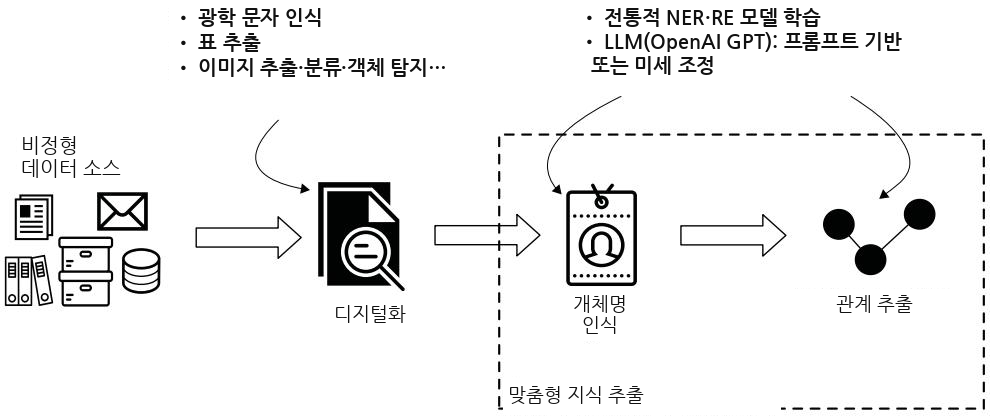

*그림 5.1 — 도메인 특화 비정형 텍스트에서 구조화된 지식으로 가는 경로. 왼쪽의 `Unstructured data sources`(신문·이메일·문서 상자·데이터베이스 아이콘)가 `Digitization` 을 거쳐, 점선 상자로 묶인 `Custom knowledge extraction`(= `Named entity recognition` → `Relation extraction`)으로 들어간다. 위쪽 주석 두 덩이가 각 단계의 기술을 짚는다 — 디지털화 쪽은 **광학 문자 인식(OCR)·표 추출·이미지 추출**, 지식 추출 쪽은 **전통적 NER·RE 모델 학습** 또는 **LLM(프롬프트 기반 또는 파인튜닝)** 이다. 갈림길이 정확히 여기서 생긴다. 이 장은 점선 상자 안만 다루고, 그중에서도 **아래쪽 갈래(LLM)** 를 택한다.*

> **디지털화는 이 장의 범위가 아니다.** 그림의 첫 단계인 OCR·스캔 처리와, 거기서 나온 텍스트를 실제 그래프로 적재하는 뒷단은 [6장](../../../chapter_06_building_knowledge_graphs_with_large_language_models/src/ch06/06_chapter_guide.ipynb)이 다룬다. 5장은 **이미 텍스트가 된 일기 한 문단** 에서 시작한다.

---
## 5.2 지식 추출의 핵심 개념 — 개체와 관계, 두 개의 기둥

그림 5.1 의 점선 상자 안에는 **상자 두 개** 가 들어 있었다. `Named entity recognition` 과 `Relation extraction` 이다. 이 절은 그 둘이 각각 무엇인지 정의한다. 순서가 이런 이유는 단순하다 — **점을 먼저 찍어야 선을 그을 수 있기 때문이다.**

| 단계 | 하는 일 | 그래프에서 무엇이 되나 |
| --- | --- | --- |
| **개체명 인식(NER)** | 원본 텍스트에서 개체명이 언급된 부분을 찾아 미리 정한 범주에 넣는다 | **노드** 와 그 **라벨** |
| **관계 추출(RE)** | 개체 쌍 사이의 의미적 관계를 찾아낸다 | **관계** 와 그 **유형** |

둘 중 하나만 해서는 지식 그래프가 되지 않는다. 개체만 뽑으면 흩어진 점들이고, 그 점들을 잇는 선이 있어야 비로소 그래프다. 이 장이 뒤에서 쓰는 출력 형식이 `[개체1, 개체1 유형, 관계, 개체2, 개체2 유형]` 이라는 **다섯 칸짜리 튜플** 인 것은 그래서다 — 한 줄이 노드 두 개와 그 사이의 관계 하나를 동시에 담는다.

---
### 5.2.1 개체명 인식하기 — 글 속 주인공 찾아내기

**개체명 인식(named entity recognition, NER)** 은 원본 텍스트 안에서 개체명이 언급된 부분을 찾아 **미리 정해 둔 범주** 에 넣도록 학습된 머신러닝 분류 시스템이다. "이 단어는 사람 이름", "이건 기관 이름" 하고 표시해 주는 일이다. 쓰임새는 넓다.

- 여러 데이터 원천의 문서를 서로 연결해 통찰을 발견하기 (금융 문서에 언급된 사람을 기업 등록부와 잇기)
- 회사의 정보 관리와 데이터 거버넌스 개선
- 데이터 컴플라이언스 시스템의 기반
- 검색 능력 향상
- 원인과 결과 잇기 (기상 조건과 항공기 지연)

문제는 **기성품으로 부족하다** 는 것이다. 오픈소스 NLP 라이브러리들은 Person·Location·Organization 같은 일반 범주를 바로 쓸 수 있게 제공하지만, 이 장의 데이터에서는 그것으로 충분하지 않다. 그림 5.2 가 그 이유를 한 장으로 보여 준다.

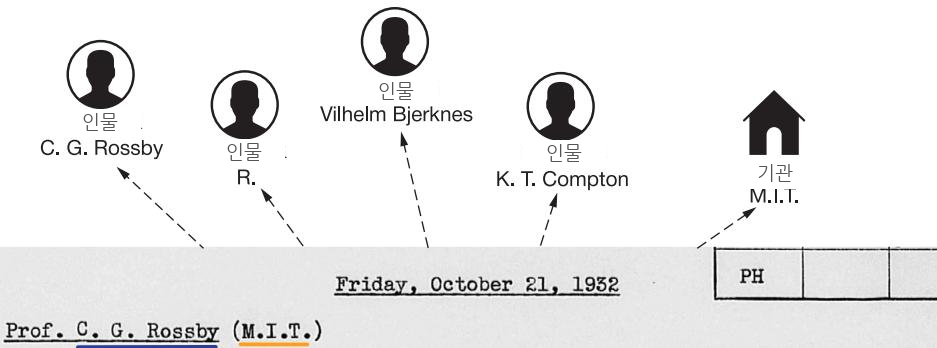

*그림 5.2 (위) — 워런 위버 일기 항목의 **윗부분**. 스캔 이미지 위에 점선 화살표로 개체 주석이 달려 있다. `Person` 으로 표시된 것이 **C. G. Rossby · R. · Vilhelm Bjerknes · K. T. Compton** 넷, `Organization` 으로 표시된 것이 **M.I.T.** 하나다. 원본 타자 문서의 날짜 줄 `Friday, October 21, 1932` 과 첫 줄 `Prof. C. G. Rossby (M.I.T.)` 가 보인다. **주목할 것은 두 번째 Person 이 그냥 `R.` 이라는 점이다** — 인터뷰 대상이 첫머리에서만 성과 이름을 다 갖추고, 그 뒤로는 이니셜 하나로만 불린다.*

원본 일기 본문은 원서 md 에서 그림 두 장 **사이에 OCR 텍스트로** 끼어 있다. 그 부분을 옮기면 이렇다.

> R.은 빌헬름 비에르크네스(Vilhelm Bjerknes, 오슬로 대학교 기계·수리물리학 교수)의 옛 제자이며, 학창 시절에는 로슬란트(Rossland)와 가깝게 지냈다.
>
> MIT의 대기 관측 연구 프로젝트에 관한 핵심 자료는 K. T. 콤프턴 총장의 메모에 담겨 있다. R.은 이 프로젝트가 자신이 이끌고 있는 기상 연구 전반의 프로그램에서 필수적인 부분을 이룬다고 여긴다. … 뉴잉글랜드에는 기상국의 연(kite) 관측소가 하나도 없는데, 이 지역은 태평양 폭풍 경로와 멕시코만 폭풍 경로가 교차하는 곳이어서 특히 흥미롭다. 이곳은 **북극 기단과 온대 기단 사이의 충돌** 에 관한 비에르크네스의 이론을 이 대륙에서 적용해 볼 수 있는 전략적 지점이다.

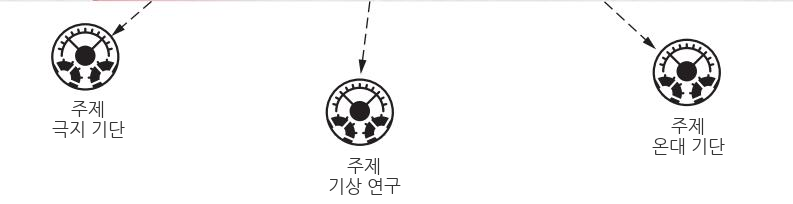

*그림 5.2 (아래) — 같은 일기 항목의 **아랫부분**. 여기 달린 주석은 전부 `Topic` 이다 — **polar air masses · meteorological research · temperate air masses**. 위쪽 그림의 Person/Organization 과 달리 이것들은 **어떤 일반 NER 모델의 범주에도 없는 개념** 이다. 이 세 줄이 5.2.1 절 전체의 논거다.*

> **원서에서 그림 5.2 는 이미지 두 장으로 쪼개져 있다.** 캡션은 아래쪽 이미지 뒤에만 붙어 있고, 그 사이에 일기 본문이 텍스트로 끼어 있다. 한 장으로 착각하면 위쪽의 Person/Organization 주석을 통째로 놓친다. 이 노트북은 `fig5-2a`·`fig5-2b` 로 나눠 싣고 각각이 무엇을 주석했는지 밝힌다. 같은 내용이 교재 루트 [`errata.toml`](../../../errata.toml) 에 `kind = "extraction"`, `status = "editorial"` 로 기록돼 있다 — 책 내용이 틀린 것이 아니라 PDF→md 변환의 손상이다.

이 일기 항목에 등장하는 **연구 분야 유형의 주제는 넷** 이다: "aerological research(대기 관측 연구)", "meteorological research(기상 연구)", "polar air masses(북극 기단)", "temperate air masses(온대 기단)". 사전 기반(dictionary-based) NER 로는 하나도 찾을 수 없다 — 미리 만들어 둔 사전에 없는 표현이기 때문이다. 게다가 책은 Topic 개체가 다시 세 하위 유형(**연구 분야 · 기술 · 질병**)으로 갈린다고 말한다.

그래서 길은 둘뿐이다.

| 길 | 무엇을 하나 | 대가 |
| --- | --- | --- |
| **맞춤형 NER 모델을 학습** | 이 도메인의 데이터에 사람이 라벨을 달아 모델을 새로 학습시킨다 | 학습 데이터셋 제작 비용. 5.3.4 절이 이 대가를 계산한다 |
| **LLM 의 힘을 빌린다** | 프롬프트로 "이런 것을 찾아라" 하고 말한다 | 5.3 절 전체가 이 길이다 |

이 장은 두 번째를 택한다. 다만 그 선택을 **무조건 옳은 것으로 놓지는 않는다** — 5.3.4 절이 돌아와서 조건을 따진다.

---
### 5.2.2 관계 추출하기 — 개체들을 이어 주는 실

**관계 추출(relation extraction, RE)** 은 텍스트 문서 안에서 **개체 쌍 사이의 의미적 관계** 를 찾아내는 일이다. 책의 예문은 이렇다.

> "Jane Austen, Victorian era writer, is currently employed by Google."

이 문장에는 PERSON 부류의 개체 "Jane Austen" 과 ORGANIZATION 부류의 개체 "Google" 이 있고, 둘은 **긴밀하게 이어져 있다** — 하나가 다른 하나의 피고용인이다. 이 "이어져 있음"을 붙잡는 것이 진짜 지식 그래프를 만드는 일이다.

여기서 5.3.2 절 전체의 씨앗이 되는 문제가 처음 나온다. **같은 사실을 여러 방식으로 모델링할 수 있다는 것.**

| 표현 | 방향 | 관계 유형 |
| --- | --- | --- |
| `Jane Austen -[:WORKS_FOR]-> Google` | 사람 → 조직 | `WORKS_FOR` |
| `Jane Austen <-[:EMPLOYS]- Google` | 조직 → 사람 | `EMPLOYS` |

둘 다 맞고, 둘 다 같은 사실을 담는다. 책의 결론은 하나다 — **중요한 것은 여러 문서에 걸쳐 일관성을 지키는 것이다.** 같은 개념을 어떤 문서에서는 `WORKS_FOR` 로, 다른 문서에서는 `EMPLOYS` 로 적으면 나중에 그래프를 질의할 수 없다.

이 요구가 왜 심각한지는 5.3.2 절에서 숫자로 드러난다. 사람이 두 가지 중 하나를 **골라서 지키는** 것과 달리, 아무 지시 없이 놓아둔 LLM 은 같은 개념에 **관계 유형을 열아홉 가지에서 스물두 가지까지** 붙인다. 일관성은 저절로 오지 않는다.

---
## 5.3 대규모 언어 모델로 지식 그래프 만들기 — 판을 바꾸는 도구

5.2 절까지가 이른바 **"전통적" NLP** 다. 과제에 맞는 학습 데이터셋을 만들고, 가장 좋은 모델 구조를 찾고, 하이퍼파라미터를 미세 조정한다. 그 과정의 상당 부분은 학습 데이터의 품질을 끌어올리는 일에 들어가고, 그 일은 좋게 말해도 고되다.

2022년 말 OpenAI 가 GPT-3.5 계열과 **ChatGPT** 를 공개하면서 이 그림이 달라졌다. 이런 **생성 모델(generative model)** 을 **대규모 언어 모델(large language model, LLM)** 이라 부르고, [트랜스포머(Transformer) 구조](https://arxiv.org/abs/1706.03762) 위에 세워져 있다.

LLM 을 이 문제에 쓸 수 있게 만드는 개념이 **전이 학습(transfer learning)** 이다. 무작위로 가려진 토큰을 맞히는 것 같은 **일반적 과제** 에서 배운 언어 패턴과 지식을, 관계 추출 같은 **다른 과제** 에 그대로 재사용하는 능력이다. 모델을 처음부터 학습시키는 것이 아니라 이미 배운 가중치를 다시 쓰므로, **사람이 라벨을 단 데이터가 훨씬 적어도** 같은 정확도에 이른다. 5.2.1 절에서 본 "맞춤형 NER 모델을 학습해야 한다"는 부담이 여기서 줄어든다.

### 무엇이 LLM 을 예외적으로 만드나 — 그리고 무엇이 패러다임을 바꿨나

두 가지다. **모델의 복잡도**(파라미터 개수)와 **학습 말뭉치의 크기·품질** 이다. 신경망이 클수록 같은 성능(테스트셋 손실 기준)에 이르는 데 필요한 데이터 표본이 적어진다는 [스케일링 관계](https://arxiv.org/abs/2001.08361)가 알려져 있다. 그런데 이것은 양만의 문제가 아니다.

| 패러다임 | 초점 | 극단으로 가면 |
| --- | --- | --- |
| **모델 중심(model-centric)** | 가장 좋은 모델 구조를 찾고 하이퍼파라미터를 미세 조정한다 | 데이터 품질 문제를 무시한다. 엉터리 데이터를 넣으면 엉터리 예측이 나온다 |
| **데이터 중심(data-centric)** | 학습에 쓰는 데이터의 품질(과 양)을 끌어올리는 데이터 엔지니어링 | 오늘날 LLM 이 워낙 강력해져 **과제를 자연어로 표현하기만 하면** 답이 나온다 |

마지막 칸이 이 장의 전제다. **모델 엔지니어링이 더 이상 필요하지 않다.** 대신 **프롬프트 엔지니어링** 이 그 자리에 들어온다.

### 한계 — 환각

가장 중요한 한계는 **환각(hallucination)** 이다. 학습 데이터에 근거가 전혀 없는데도 모델이 "사실"을 지어내고 잘못된 추론을 하는 경향이다. NASA SLS 로켓의 비용을 물었는데 그 정보가 학습 데이터에 없다면, 모델은 아무 숫자나 골라 놓고 그것이 비용이라고 **자신 있게** 주장할 수 있다.

이 책이 계속 쓰는 비유가 여기서 다시 나온다 — **LLM 은 아는 것이 많지만 없는 사실을 그럴듯하게 지어내는 달변가** 이고, **KG 는 검증된 사실만 적어 둔 사실 대장** 이다. 그래서 저자들은 이 모델들을 "AI" 라고 부르지 않겠다고 못 박고, 대신 **LLM 을 시켜 더 포괄적이고 깨끗한 지식 그래프를 만들자** 고 제안한다. 달변가를 답으로 쓰는 것이 아니라, 달변가에게 **사실 대장을 채우는 일** 을 시키는 것이다.

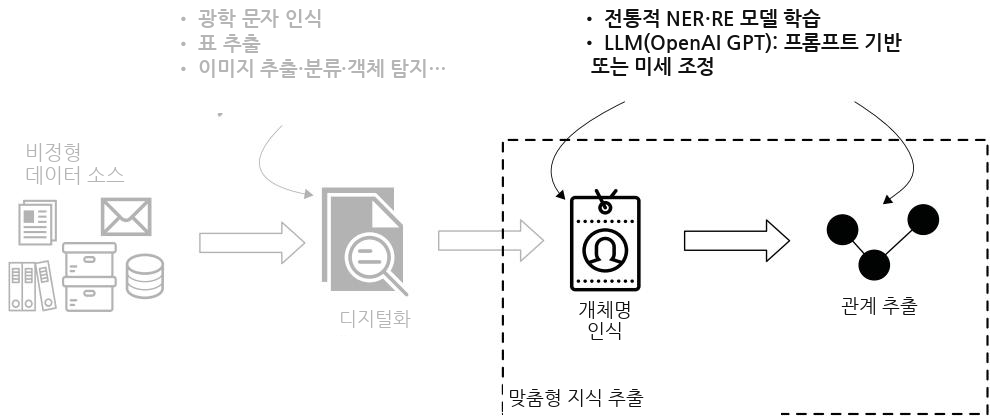

*그림 5.3 — 텍스트 데이터를 구조화된 지식으로 바꾸는 정신 모형: LLM 을 이용한 NER 과 RE. **그림 5.1 과 같은 도식인데 강조가 다르다.** 왼쪽의 `Unstructured data sources` 와 `Digitization`, 그리고 OCR·표 추출·이미지 추출 주석이 전부 **회색으로 흐려져 있고**, 점선 상자 안의 `Named entity recognition` → `Relation extraction` 과 그 위 주석(`Train traditional NER and RE models` / `LLMs (OpenAI's GPT): prompt-based or fine-tuned`)만 검게 남았다. 이 장이 다루는 범위가 어디까지인지를 같은 그림의 명암으로 표시한 것이다.*

---
### 5.3.1 LLM 활용하기 — 그냥 쓸까, 길들여 쓸까

LLM 으로 지식 그래프를 만드는 데는 길이 둘이다.

| 길 | 무엇을 하나 | 비용 |
| --- | --- | --- |
| **프롬프트 기반 추론(prompt-based inference)** | 과제를 자연어로 표현하고 (선택적으로) 예시를 붙인다. 손질 없이 바로 쓴다 | 거의 없다. 반복이 빠르다 |
| **파인튜닝(fine-tuning)** | 작은 학습 데이터셋으로 모델을 우리 도메인에 맞게 추가 학습시킨다 | 시간과 돈. 대신 더 안정적이고 정확한 출력 |

과제를 표현한 것을 **프롬프트(prompt)** 라 하고, 주어진 과제에 가장 성능이 좋은 프롬프트를 찾아가는 반복 과정을 **프롬프트 엔지니어링(prompt engineering)** 이라 부른다.

이 장이 쓰는 모드는 **텍스트 완성(text completion)** 이다. 모델에 프롬프트를 주면 그 안의 맥락과 과제 설명에 맞춰 텍스트를 생성한다. 목표는 텍스트 입력에서 개체와 그 사이의 관계를 찾아내는 것이다.

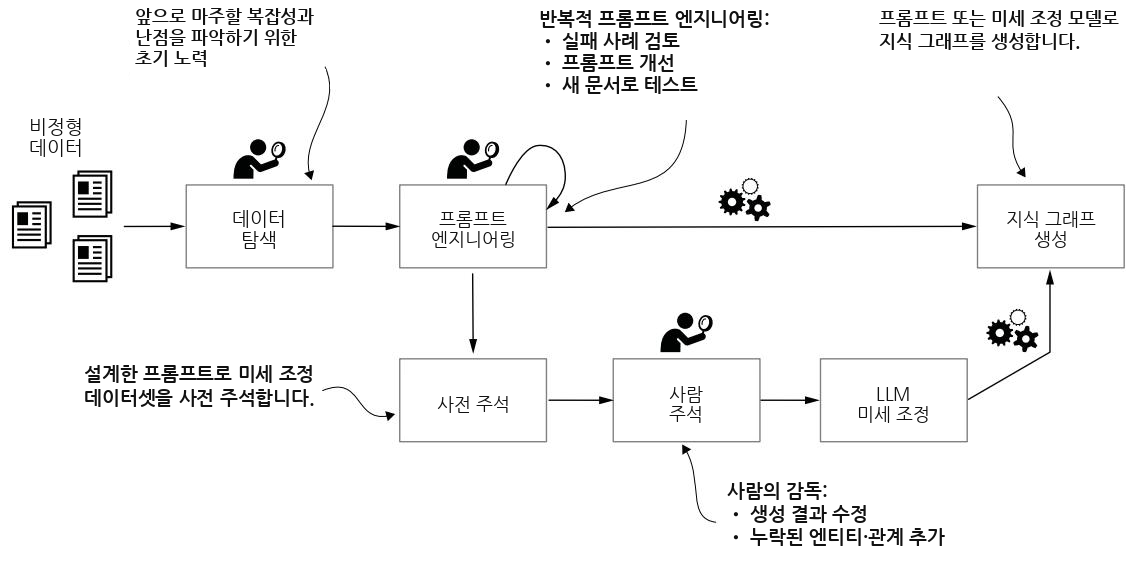

*그림 5.4 — 텍스트 데이터로 지식 그래프를 만들 때 LLM 의 두 가지 역할. 왼쪽 `Unstructured data` 에서 시작해 `Data exploration` → `Promt engineering`(원문 오탈자 그대로) 으로 가고, 거기서 **두 갈래** 로 나뉜다. 위쪽은 곧바로 `KG generation` 으로, 아래쪽은 `Preannotation` → `Human annotation` → `Fine-tune LLM` 을 거쳐 `KG generation` 으로 합류한다. 프롬프트 엔지니어링 상자에 **자기 자신으로 돌아오는 화살표** 가 붙어 있고 그 주석이 이 절의 핵심이다 — `Examine failures · Improve the prompt · Test on new documents`. 사람 아이콘이 붙은 상자가 셋(`Data exploration`·`Promt engineering`·`Human annotation`)이라는 점도 눈에 띈다. 자동화된 것처럼 보이는 이 흐름에서 **사람이 판단해야 하는 자리** 가 그만큼 있다는 뜻이다.*

### 왜 데이터 탐색이 먼저인가

데이터 과학 프로젝트가 늘 그렇듯 **데이터 탐색(data exploration)** 부터 시작한다. 도메인과 난관과 합리적 기대치를 알아야 하기 때문이다. 이 장에서 그 탐색이 건진 것이 5.2.1 절의 관찰이다 — **인터뷰 대상 C. G. 로스비는 항목 첫머리에서만 성과 이름을 다 갖추고 그 뒤로는 "R." 로만 불린다.** 이 사실을 미리 알았기 때문에 프롬프트 v2 에 "사람은 처음에 전체 이름으로, 그다음엔 성이나 이니셜로만 언급된다"는 안내를 넣을 수 있었다. 탐색을 건너뛰었다면 그 문장은 나오지 않았을 것이다.

그다음이 프롬프트 엔지니어링이고, 대개 **여러 번의 반복** 이 필요하다. 단어 몇 개만 바꿔도 성능이 크게 달라지기 때문이다. 과제를 최대한 정확히 기술해 모호함을 줄여야 한다 — 모호하게 두면 모델이 답을 지나치게 창의적으로 지어낼 여지를 준다.

프롬프트 엔지니어링을 마치면 두 갈래 중 하나에 이른다. 품질에 만족해 곧바로 KG 생성으로 가거나, 프롬프트만으로는 감당하기엔 과제가 너무 복잡하다는 것을 깨닫거나. 후자면 작은 학습 데이터셋(**과제 설명 없는 순수 입력 문서** 와 기대 출력의 쌍)을 준비해 파인튜닝한다. 이때 **앞서 한 프롬프트 엔지니어링은 헛수고가 아니다** — 사람이 최종 주석을 달기 전에 그 프롬프트로 데이터셋을 **초벌 주석(preannotate)** 해 둘 수 있다. 그림의 `Preannotation` 상자가 그것이다.

이 노트북이 실행하는 것은 **위쪽 갈래뿐** 이다. 파인튜닝은 학습 데이터셋과 유료 API 가 필요하고 이 장에 리스팅도 없다.

---
### 5.3.2 프롬프트 엔지니어링 예시 — 프롬프트를 진화시켜 가기

여기서부터가 이 장의 본론이자 이 노트북의 무게중심이다. **같은 문단, 같은 모델, 같은 설정에 프롬프트만 세 번 고쳐 넣고 무엇이 달라지는지 본다.**

책이 처리하는 문단은 1932년 11월 9일 존스홉킨스 대학교 화학과 방문 기록이다. 워런 위버(WW)가 프레이저 박사와 함께 학과를 방문해, D. H. 앤드루스 교수와 J. B. 마이어의 연구를 전해 듣는 내용이다. **짧은 한 문단인데도** 사람 여섯, 조직 하나, 연구 주제 여럿, 사제 관계와 협업 관계가 얽혀 있다.

세 판본이 무엇을 더하는지 미리 표로 두면 이렇다.

| 판본 | 책 리스팅 | 저장소 파일 | 무엇을 더했나 |
| --- | --- | --- | --- |
| **v1** | 5.1 | [`listings/listing_2.py`](./listings/listing_2.py) | 과제 설명 + 예시 하나(원샷). "가능한 한 많은 개체와 관계를 찾아라" |
| **v2** | 5.4 | [`listings/listing_5.py`](./listings/listing_5.py) | **관심 있는 개체 부류·관계 유형 목록** 과, 이니셜·약칭 습관에 대한 안내 두 문단 |
| **v3** | 5.6 | [`listings/listing_7.py`](./listings/listing_7.py) | **예시를 복잡하게** 바꾸고 기대 출력을 4줄에서 7줄로 늘렸다. 일기의 화자가 WW 임을 알리는 절도 추가 |

그리고 각 판본의 출력이 책 5.3·5.5·5.7 이다. 이 셋은 **코드가 아니라 GPT 출력** 이라 저장소에 파일이 없다 — 위 헬퍼 셀의 대조표에서 `해설판 본문` 으로 나온 세 줄이 그것이다.

#### 프롬프트는 어떻게 메시지가 되나

책 5.1 은 파이썬 코드처럼 보이지만 실질은 **문자열 세 개** 다. 책 5.2 의 `openai_query()` 가 그 셋을 서로 다른 역할에 배치한다.

| `prompt_segments` 키 | 메시지 역할 | 무엇을 담나 |
| --- | --- | --- |
| `task` | `system` | 과제 설명. "너는 …하는 전문가다" |
| `example` | `user` | 예시 입력 문장 |
| `example_output` | `assistant` | 그 입력에 대해 **모델이 냈어야 할** 출력 |
| (마지막) | `user` | 진짜 처리할 텍스트 |

즉 "이런 질문에는 이렇게 답하는 거야" 하고 **한 차례 시범을 보인 뒤**(원샷 학습) 진짜 과제를 던지는 구조다. `temperature=0.` 은 5.3.3 절에서 설명하듯 사실 추출 과제에서 출력을 최대한 결정적으로 만들기 위한 설정이다 — 다만 아래에서 보듯 **그것으로 재현성이 보장되지는 않는다.**

In [3]:
"""책 5.1(프롬프트 v1) · 5.2(API 호출) — 첫 판본을 그대로 돌려 본다.

이 셀이 세 가지를 준비하고 v1 을 처리한다.

  1) 세 프롬프트 모듈을 임포트한다. 셋 다 prompt_segments 라는 dict 하나만 담은
     파일이라 임포트 자체가 곧 "리스팅 실행" 이다 — API 가 없어도 여기까지는 된다.
  2) 처리할 일기 토막을 업스트림 파일에서 그대로 가져온다 (diary_text()).
  3) 책 지면의 출력(5.3)과 2026-07-25 실측을 **같은 파서로** 집계한다.

업스트림 파일은 한 글자도 고치지 않는다. 두 곳에서 그 원칙이 걸린다.

  * listing_3.py 는 세 프롬프트 중 하나를 임포트하도록 맨 위 두 줄이 주석 처리돼
    있다(#from listing_5 import prompt_segments). 파일을 편집해 주석을 옮기는 대신
    이미 임포트해 둔 모듈의 prompt_segments 를 **인자로** 넘긴다 —
    openai_query(client, prompt_segments, query) 가 그것을 인자로 받게 쓰여 있다.
  * listing_3.OPENAI_MODEL 은 "gpt-4o-mini" 로 박혀 있고 지금 프록시에 그 모델이
    없다. llm.override_module_model() 로 **런타임에 모듈 상수만** 바꾼다.

⏱️ RUN_LLM = False 면 1초 미만. True 면 API 호출 한 번에 16.0~83.8초.
"""
import json
import time

import listing_2                # 책 5.1 — 프롬프트 v1
import listing_3                # 책 5.2 — OpenAI API 호출
import listing_5                # 책 5.4 — 프롬프트 v2
import listing_7                # 책 5.6 — 프롬프트 v3

PROMPT_MODULE = {"5.1": listing_2, "5.4": listing_5, "5.6": listing_7}
VERSION = {"5.1": "v1", "5.4": "v2", "5.6": "v3"}
BOOK_OUTPUT_OF = {"5.1": "5.3", "5.4": "5.5", "5.6": "5.7"}

# ── 2026-07-25 실측 보존 ──────────────────────────────────────────────────────
# RUN_LLM 기본값이 False 라 깨끗한 환경의 Run All 은 API 를 부르지 않는다. 그래서
# 실제로 불렀을 때 무엇이 나왔는지를 여기 그대로 남긴다. 모델 gpt-5.4-mini,
# temperature=0, max_tokens=2000, 입력은 아래 DIARY 와 같은 문단이다.
#
# 값이 아니라 **원문** 을 보존하는 이유가 있다. 아래 집계 함수가 실제 응답과 똑같은
# 코드로 이것을 처리하므로, 요약 표의 숫자를 손으로 옮겨 적을 일이 없어진다.
#
# v1 세 회차가 서로 다르다는 점에 주목하라 — temperature=0 인데도 그렇다.
# v2 1회차는 아예 **JSON 배열 형태** 로 답했다. 출력 형식조차 실행마다 흔들린다.
OBSERVED = {
    ("5.1", 1): (36.9, """["Johns Hopkins University Chemistry Department", "department", "has visitor", "WW", "person"]
["WW", "person", "visited with", "Dr. Frazer", "person"]
["Dr. Frazer", "person", "has title", "Baker Professor of Chemistry", "title"]
["Johns Hopkins University Chemistry Department", "department", "has undergraduate students", "239 undergraduate chemistry students", "student group"]
["Johns Hopkins University Chemistry Department", "department", "has graduate students", "116 graduate chemistry students", "student group"]
["116 graduate chemistry students", "student group", "include", "holders of special State fellowships in chemistry under the New Plan", "fellowship group"]
["D. H. Andrews", "person", "has title", "Professor of Chemistry", "title"]
["D. H. Andrews", "person", "is a", "physical chemist", "occupation"]
["D. H. Andrews", "person", "specializes in", "thermodynamics", "field"]
["D. H. Andrews", "person", "measures", "specific heats of organic compounds", "topic"]
["D. H. Andrews", "person", "uses", "straight calorimetric method", "method"]
["D. H. Andrews", "person", "interested in", "mechanical models of various atoms", "topic"]
["mechanical models of various atoms", "topic", "demonstrate theory of", "Raman spectra", "field"]
["J. B. Mayer", "person", "has title", "Associate in Chemistry", "title"]
["J. B. Mayer", "person", "was a former student of", "G. N. Lewis", "person"]
["J. B. Mayer", "person", "works with", "Max Born", "person"]
["J. B. Mayer", "person", "works at summers in", "Gottingen", "place"]
["J. B. Mayer", "person", "specializes in", "energetics of crystal lattices", "field"]
["Mayer's wife", "person", "prepared", "new edition of Born's treatise", "publication"]
["Born's treatise", "publication", "is on", "energetics of crystal lattices", "field"]
["Mrs. Wintner", "person", "works in", "Mayer's laboratory", "laboratory"]
["Mrs. Wintner", "person", "works on", "experimental problem", "topic"]"""),
    ("5.1", 2): (31.2, """["Johns Hopkins University", "organization", "has department", "Chemistry Department", "department"]
["WW", "person", "visited", "Chemistry Department", "department"]
["WW", "person", "visited with", "Dr. Frazer", "person"]
["Dr. Frazer", "person", "has title", "Baker Professor of Chemistry", "title"]
["Chemistry Department", "department", "has students", "239 undergraduate students of chemistry", "student group"]
["Chemistry Department", "department", "has students", "116 graduate students of chemistry", "student group"]
["Graduate students of chemistry", "student group", "include", "holders of special State fellowships in chemistry", "fellowship holders"]
["Special State fellowships in chemistry", "fellowship", "are under", "New Plan", "plan"]
["D.H. Andrews", "person", "has title", "Professor of Chemistry", "title"]
["D.H. Andrews", "person", "is a", "physical chemist", "occupation"]
["D.H. Andrews", "person", "specializes in", "thermodynamics", "field"]
["D.H. Andrews", "person", "measures", "specific heats of organic compounds", "research topic"]
["D.H. Andrews", "person", "uses", "straight calorimetric method", "method"]
["D.H. Andrews", "person", "is interested in", "making mechanical models of various atoms", "research topic"]
["Mechanical models of various atoms", "research topic", "demonstrate", "theory of Raman spectra", "theory"]
["J.B. Mayer", "person", "has title", "Associate in Chemistry", "title"]
["J.B. Mayer", "person", "was student of", "G.N. Lewis", "person"]
["J.B. Mayer", "person", "works with", "Max Born", "person"]
["J.B. Mayer", "person", "works at summers in", "Gottingen", "location"]
["J.B. Mayer", "person", "specializes in", "energetics of crystal lattices", "field"]
["Mayer's wife", "person", "prepared new edition of", "Born's treatise on energetics of crystal lattices", "publication"]
["Mrs. Wintner", "person", "is wife of", "Wintner", "person"]
["Mrs. Wintner", "person", "works on", "experimental problem", "research topic"]
["Mrs. Wintner", "person", "works in", "Mayer's laboratory", "laboratory"]
["Andrews", "person", "describes", "J.B. Mayer", "person"]
["Andrews", "person", "says is", "young", "attribute"]
["Andrews", "person", "says is", "enthusiastic and able man", "attribute"]"""),
    ("5.4", 1): (27.8, """[
  ["D. H. Andrews", "person", "works on", "thermodynamics", "occupation"],
  ["D. H. Andrews", "person", "works on", "specific heats of organic compounds", "occupation"],
  ["D. H. Andrews", "person", "works on", "mechanical models of atoms", "occupation"],
  ["D. H. Andrews", "person", "works on", "Raman spectra", "occupation"],
  ["J. B. Mayer", "person", "student of", "G. N. Lewis", "person"],
  ["J. B. Mayer", "person", "works with", "Max Born", "person"],
  ["J. B. Mayer", "person", "works on", "energetics of crystal lattices", "occupation"],
  ["Andrews", "person", "talked about", "J. B. Mayer", "person"],
  ["Mrs. Wintner", "person", "works with", "J. B. Mayer", "person"],
  ["Mrs. Wintner", "person", "works on", "experimental problem", "occupation"],
  ["Dr. Frazer", "person", "works for", "Johns Hopkins University Chemistry Department", "organization"],
  ["D. H. Andrews", "person", "works for", "Johns Hopkins University Chemistry Department", "organization"],
  ["J. B. Mayer", "person", "works for", "Johns Hopkins University Chemistry Department", "organization"],
  ["WW", "person", "visited", "Johns Hopkins University Chemistry Department", "organization"],
  ["Wednesday, November 9, 1932", "date", "associated with", "Johns Hopkins University Chemistry Department", "organization"]
]"""),
    ("5.4", 2): (36.0, """["Dr. Frazer", "person", "works for", "Johns Hopkins University Chemistry Department", "organization"]
["Dr. Frazer", "person", "works on", "chemistry", "occupation"]
["D. H. Andrews", "person", "works for", "Johns Hopkins University Chemistry Department", "organization"]
["D. H. Andrews", "person", "works on", "physical chemistry", "occupation"]
["D. H. Andrews", "person", "works on", "thermodynamics", "occupation"]
["D. H. Andrews", "person", "works on", "specific heats of organic compounds", "occupation"]
["D. H. Andrews", "person", "works on", "Raman spectra", "occupation"]
["J. B. Mayer", "person", "works for", "Johns Hopkins University Chemistry Department", "organization"]
["J. B. Mayer", "person", "student of", "G. N. Lewis", "person"]
["J. B. Mayer", "person", "works with", "Max Born", "person"]
["J. B. Mayer", "person", "works on", "energetics of crystal lattices", "occupation"]
["Mrs. Wintner", "person", "works with", "J. B. Mayer", "person"]
["Mrs. Wintner", "person", "works on", "experimental problem", "occupation"]"""),
    ("5.6", 1): (50.9, """["Warren Weaver", "person", "visited", "Johns Hopkins University Chemistry Department", "organization"]
["Warren Weaver", "person", "visited with", "Dr. Frazer", "person"]
["Dr. Frazer", "person", "has title", "Baker Professor of Chemistry", "occupation"]
["Dr. Frazer", "person", "works for", "Johns Hopkins University Chemistry Department", "organization"]
["D. H. Andrews", "person", "has title", "Professor of Chemistry", "occupation"]
["D. H. Andrews", "person", "works for", "Johns Hopkins University Chemistry Department", "organization"]
["D. H. Andrews", "person", "works on", "physical chemistry", "occupation"]
["D. H. Andrews", "person", "works on", "thermodynamics", "occupation"]
["D. H. Andrews", "person", "works on", "specific heats of organic compounds", "occupation"]
["D. H. Andrews", "person", "works on", "straight calorimetric method", "occupation"]
["D. H. Andrews", "person", "works on", "mechanical models of atoms", "occupation"]
["D. H. Andrews", "person", "works on", "Raman spectra theory", "occupation"]
["J. B. Mayer", "person", "has title", "Associate in Chemistry", "occupation"]
["J. B. Mayer", "person", "works for", "Johns Hopkins University Chemistry Department", "organization"]
["J. B. Mayer", "person", "student of", "G. N. Lewis", "person"]
["J. B. Mayer", "person", "works with", "Max Born", "person"]
["J. B. Mayer", "person", "works at", "Gottingen", "location"]
["J. B. Mayer", "person", "works on", "energetics of crystal lattices", "occupation"]
["Mrs. Wintner", "person", "works on", "experimental problem", "occupation"]
["Wednesday, November 9, 1932", "date", "related to", "Johns Hopkins University Chemistry Department", "organization"]"""),
    ("5.1", 3): (16.0, """["Johns Hopkins University Chemistry Department", "organization", "has visitor", "WW", "person"]  
["WW", "person", "visited with", "Dr. Frazer", "person"]  
["Dr. Frazer", "person", "has title", "Baker Professor of Chemistry", "title"]  
["Johns Hopkins University Chemistry Department", "organization", "has undergraduate chemistry students", "239", "number"]  
["Johns Hopkins University Chemistry Department", "organization", "has graduate chemistry students", "116", "number"]  
["Graduate chemistry students", "group", "include", "holders of special State fellowships in chemistry under the New Plan", "group"]  
["D. H. Andrews", "person", "has title", "Professor of Chemistry", "title"]  
["D. H. Andrews", "person", "is a", "physical chemist", "profession"]  
["D. H. Andrews", "person", "specializes in", "thermodynamics", "field"]  
["D. H. Andrews", "person", "measures", "specific heats of organic compounds", "research topic"]  
["D. H. Andrews", "person", "uses method", "straight calorimetric method", "method"]  
["D. H. Andrews", "person", "interested in", "mechanical models of various atoms", "research topic"]  
["Mechanical models of various atoms", "research topic", "demonstrate theory of", "Raman spectra", "theory"]  
["J. B. Mayer", "person", "has title", "Associate in Chemistry", "title"]  
["J. B. Mayer", "person", "was student of", "G. N. Lewis", "person"]  
["J. B. Mayer", "person", "works with", "Max Born", "person"]  
["J. B. Mayer", "person", "works at", "Gottingen", "location"]  
["J. B. Mayer", "person", "specializes in", "energetics of crystal lattices", "field"]  
["J. B. Mayer's wife", "person", "prepared", "new edition of Born's treatise on energetics of crystal lattices", "publication"]  
["Mrs. Wintner", "person", "is wife of", "the mathematician", "person"]  
["Mrs. Wintner", "person", "works on", "an experimental problem", "research topic"]  
["D. H. Andrews", "person", "said that", "J. B. Mayer is young and enthusiastic and able", "statement"]"""),
    ("5.4", 3): (19.2, """[
  ["D. H. Andrews", "person", "works for", "Johns Hopkins University Chemistry Department", "organization"],
  ["D. H. Andrews", "person", "works on", "thermodynamics", "occupation"],
  ["D. H. Andrews", "person", "works on", "specific heats of organic compounds", "occupation"],
  ["D. H. Andrews", "person", "works on", "mechanical models of atoms", "occupation"],
  ["D. H. Andrews", "person", "talked about", "J. B. Mayer", "person"],
  ["J. B. Mayer", "person", "works on", "energetics of crystal lattices", "occupation"],
  ["J. B. Mayer", "person", "student of", "G. N. Lewis", "person"],
  ["J. B. Mayer", "person", "works with", "Max Born", "person"],
  ["Mrs. Wintner", "person", "works for", "Mayer's laboratory", "organization"],
  ["Mrs. Wintner", "person", "works on", "experimental problem", "occupation"],
  ["Frazer", "person", "works on", "chemistry", "occupation"]
]"""),
    ("5.6", 3): (83.8, """[
  ["Warren Weaver", "person", "visited", "Johns Hopkins University Chemistry Department", "organization"],
  ["Warren Weaver", "person", "visited on", "Wednesday, November 9, 1932", "date"],

  ["Dr. Frazer", "person", "works for", "Johns Hopkins University Chemistry Department", "organization"],
  ["Dr. Frazer", "person", "has occupation", "Baker Professor of Chemistry", "occupation"],

  ["D. H. Andrews", "person", "works for", "Johns Hopkins University Chemistry Department", "organization"],
  ["D. H. Andrews", "person", "has occupation", "Professor of Chemistry", "occupation"],
  ["D. H. Andrews", "person", "specializes in", "thermodynamics", "occupation"],
  ["D. H. Andrews", "person", "works on", "specific heats of organic compounds", "occupation"],
  ["D. H. Andrews", "person", "works on", "mechanical models of various atoms", "occupation"],
  ["D. H. Andrews", "person", "works on", "theory of the Raman spectra", "occupation"],

  ["J. B. Mayer", "person", "works for", "Johns Hopkins University Chemistry Department", "organization"],
  ["J. B. Mayer", "person", "has occupation", "Associate in Chemistry", "occupation"],
  ["J. B. Mayer", "person", "student of", "G. N. Lewis", "person"],
  ["J. B. Mayer", "person", "works with", "Max Born", "person"],
  ["J. B. Mayer", "person", "specializes in", "energetics of crystal lattices", "occupation"],

  ["Mrs. Wintner", "person", "works in", "Mayer's laboratory", "location"],
  ["Mrs. Wintner", "person", "works on", "experimental problem", "occupation"]
]"""),
}


def parse_relations(raw):
    """출력에서 [E1, T1, REL, E2, T2] 다섯 칸짜리 줄만 골라 읽는다.

    모델이 앞뒤에 설명 문장을 붙이거나 전체를 JSON 배열로 감싸는 일이 흔하다
    (실제로 v2 1회차가 그랬다). 그래서 줄 단위로 보고 형식에 맞지 않으면 조용히
    버린다 — 이 장의 관심은 개별 줄의 완벽함이 아니라 **관계 유형과 엔티티 유형의
    분포** 이기 때문이다. 배열을 감싼 '[' 와 ']' 줄, 줄 끝 쉼표는 이 규칙으로 함께
    걸러진다.
    """
    rows = []
    for line in raw.splitlines():
        line = line.strip().rstrip(",")
        if not (line.startswith("[") and line.endswith("]")):
            continue
        try:
            parsed = json.loads(line)
        except json.JSONDecodeError:
            continue
        if isinstance(parsed, list) and len(parsed) == 5 and all(isinstance(x, str) for x in parsed):
            rows.append(parsed)
    return rows


def subset(rows, names=("Andrews", "Mayer")):
    """책이 지면에 실은 범위로 좁힌다.

    책 5.3·5.5·5.7 은 전체 출력이 아니라 "the extracted relations featuring
    D. H. Andrews and J. B. Mayer" 라고 밝힌 **발췌** 다. 그래서 우리 전체 출력과
    바로 비교하면 사과와 오렌지를 견주게 된다. 같은 두 인물로 좁혀야 맞는 비교다.
    """
    return [r for r in rows if any(n in r[0] or n in r[3] for n in names)]


def show_stats(label, rows, indent="    "):
    """관계 줄 수 · 관계 유형 종수 · 엔티티 유형 종수를 세어 출력한다."""
    relations = sorted({r[2] for r in rows})
    types = sorted({r[1] for r in rows} | {r[4] for r in rows})
    print(f"{indent}{label}")
    print(f"{indent}  관계 {len(rows)}줄 · 관계 유형 {len(relations)}종 · 엔티티 유형 {len(types)}종")
    print(f"{indent}  관계 유형 : {', '.join(relations) or '—'}")
    print(f"{indent}  엔티티 유형: {', '.join(types) or '—'}")
    return {"rows": len(rows), "relations": relations, "types": types}


def as_range(values):
    """관측이 여럿이면 범위로 적는다. LLM 출력은 temperature=0 에서도 비결정이다."""
    low, high = min(values), max(values)
    return str(low) if low == high else f"{low}~{high}"


def report(book_no):
    """한 판본에 대해 책 지면·보존 실측을 나란히 집계한다."""
    version = VERSION[book_no]
    book_no_out = BOOK_OUTPUT_OF[book_no]
    print(f"══ {version} (책 {book_no}) 의 출력 비교")

    book_rows = parse_relations(BOOK_OUTPUT[book_no_out])
    show_stats(f"[책 {book_no_out}] 책 지면 — Andrews·Mayer 발췌", book_rows)

    runs = sorted(k[1] for k in OBSERVED if k[0] == book_no)
    full, part, seconds = [], [], []
    for run in runs:
        elapsed, raw = OBSERVED[(book_no, run)]
        rows = parse_relations(raw)
        seconds.append(elapsed)
        full.append(rows)
        part.append(subset(rows))
        print()
        show_stats(f"[실측 {run}회차 · {elapsed}초] 전체 출력", rows)
        show_stats(f"[실측 {run}회차] 같은 발췌 범위(Andrews·Mayer)", part[-1], indent="      ")

    print(f"\n    ── {version} 관측 범위 ({len(runs)}회, gpt-5.4-mini, temperature=0)")
    print(f"       전체     : 관계 {as_range([len(r) for r in full])}줄 · "
          f"관계 유형 {as_range([len({x[2] for x in r}) for r in full])}종 · "
          f"엔티티 유형 {as_range([len({x[1] for x in r} | {x[4] for x in r}) for r in full])}종")
    print(f"       발췌 범위: 관계 {as_range([len(r) for r in part])}줄 · "
          f"관계 유형 {as_range([len({x[2] for x in r}) for r in part])}종 · "
          f"엔티티 유형 {as_range([len({x[1] for x in r} | {x[4] for x in r}) for r in part])}종")
    print(f"       응답 시간: {as_range(seconds)}초")

    MEASURED[f"{version} 전체 관계 줄 수"] = as_range([len(r) for r in full])
    MEASURED[f"{version} 전체 관계 유형 종수"] = as_range([len({x[2] for x in r}) for r in full])
    MEASURED[f"{version} 전체 엔티티 유형 종수"] = as_range(
        [len({x[1] for x in r} | {x[4] for x in r}) for r in full])
    MEASURED[f"{version} 응답 시간(초)"] = as_range(seconds)
    return full


def ask(book_no, query, model=None):
    """책 5.2 의 openai_query() 를 그대로 호출한다. 프롬프트만 갈아 끼운다.

    프록시가 간헐적으로 503 을 낸다(auth_unavailable / circuit_open). 한 번의 실패로
    Run All 이 끊기지 않게 예외를 잡고 빈 문자열을 돌려준다 — 그러면 아래 집계가
    "관계 0줄" 로 나오고 나머지 셀은 계속 돌아간다.
    """
    from openai import OpenAI

    applied = llm.override_module_model(listing_3, model)   # 파일이 아니라 모듈 상수만
    print(f"── 지금 호출: 책 {book_no} ({VERSION[book_no]}) 프롬프트 · 모델 {applied}")
    client = OpenAI()          # api_key·base_url 은 llm.configure() 가 넣은 환경변수에서
    started = time.time()
    try:
        answer = listing_3.openai_query(client, PROMPT_MODULE[book_no].prompt_segments, query)
    except Exception as exc:
        print(f"    ⚠️ 호출 실패 — {type(exc).__name__}: {exc}")
        print("       프록시 503 이면 몇 분 뒤 스스로 복구된다. 이 판본만 건너뛴다.")
        return ""
    MEASURED[f"{VERSION[book_no]} 이번 실행 응답 시간(초)"] = round(time.time() - started, 1)
    return answer


LIVE = {}      # RUN_LLM = True 일 때 이번 실행의 응답이 여기 쌓인다

# ---- 책 5.1 · 5.2 원문 --------------------------------------------------------
show("5.1")
print()
show("5.2")

# ---- 처리할 일기 토막 (업스트림 파일에서 그대로) --------------------------------
DIARY = diary_text()
print(f"\n── 처리할 텍스트 (책 5.2 의 __main__ 블록, {len(DIARY)}자)\n")
print(DIARY)

# ---- v1 출력 집계 --------------------------------------------------------------
print()
report("5.1")

if RUN_LLM:
    print()
    LIVE["5.1"] = ask("5.1", DIARY)
    print()
    show_stats(f"[이번 실행] v1 전체 출력 ({LLM_MODEL})", parse_relations(LIVE["5.1"]))

── 책 Listing 5.1  Prompt version 1; identifying entities and relations
   (listings/listing_2.py  L1-L13  (파일 전체))

    prompt_segments = dict()
    
    prompt_segments['task'] = """You are an expert on constructing Knowledge Graphs from texts using named entity recognition and relation extraction.
    Given a prompt, identify as many entities and relations among them as possible and output a list of relations in the format 
    [ENTITY 1, ENTITY 1 TYPE, RELATION, ENTITY 2, ENTITY 2 TYPE]. 
    The relations are directed, so the order matters."""
    
    prompt_segments['example'] = "J.R.Smith (Prof. Phys.) is employed by MIT and mentioned another scientist, Mary Hodge, who works on cyclotron research."
    
    prompt_segments['example_output'] = """["J. R. Smith", "person", "has title", "Professor of Physics", "title"]
    ["J. R. Smith", "person", "works for", "MIT", "organization"]
    ["J. R. Smith", "person", "talked about", "Mary", "person"] 
    ["Mary", "person", "works on",

---
#### v1 이 만든 그래프 스키마를 들여다보기 — 책 5.3

책은 결과를 보고 먼저 감탄한다. 그럴 만하다. **전통적 관계 추출이었다면 세 단계가 필요했을 일** 을 한 번의 호출이 해냈다.

| 전통 NLP 라면 | LLM 은 |
| --- | --- |
| ① NER 모델이 개체 언급("Mayer")을 찾는다 | 한 번의 생성으로 전부 |
| ② **상호참조 해소(coreference resolution)** 모델이 "Mayer" 와 "he" 를 온전한 이름에 잇는다 | 문서 전체 맥락에 대한 이해로 **암묵적으로** 처리된다 |
| ③ 관계 추출 모델이 관계를 뽑는다 | |

원본 일기는 "Mayer" 또는 "he" 라고만 적었는데 출력에는 **온전한 이름** 이 들어 있다. 게다가 `"Prof. Chem."` 이 `"Professor of Chemistry"` 로, `"Assoc. in Chem."` 이 `"Associate in Chemistry"` 로 **풀려 나왔다.** 어떤 전통적 NER 모델도 줄임말에서 올바른 전체 직함을 추론하지는 못한다.

그런데 **지식 그래프로 쓸 수 있는가** 를 묻는 순간 그림이 달라진다.

#### 문제 ① — 관계 유형의 지나친 세밀함(granularity)

앤드루스 교수의 연구 주제 넷에 붙은 관계를 나란히 놓아 보자.

| 관계 유형 | 대상 |
| --- | --- |
| `specializes in` | thermodynamics |
| `is measuring` | specific heats of organic compounds |
| `is interested in` | mechanical models of various atoms |
| `demonstrates` | theory of the Raman spectra |

넷 다 **정확한 표현이다.** 그러나 넷 다 **같은 개념** 이다 — 사람이라면 전부 `works on` 하나로 묶을 것이다. GPT 는 서로 다른 유형 넷을 준 것이다. 그것도 **짧은 한 문단** 에서.

수천 쪽을 처리한 다음 "누가 유기 화합물 연구를 하는가?" 에 답하려면 어떻게 될까. `works on` 이라는 상위 개념에 해당하는 **의미가 같거나 매우 비슷한 관계 유형을 전부 알아내서** Cypher 질의에 일일이 나열해야 한다. 좋게 말해도 실용적이지 않다.

#### 문제 ② — 노드 라벨도 흩어진다

같은 문단의 연구 주제 넷에 붙은 라벨은 **셋** 이다: `field` · `research` · `theory`. 본질적으로는 다 맞다. 하지만 이것들이 진짜로 무엇인가? **전부 앤드루스 교수의 연구 주제** 다. 사람이라면 하나의 라벨(`topic` 또는 `occupation`)로 묶고 그래프에 노드 라벨 하나만 둘 것이다.

#### 문제 ③ — 예측 안정성(prediction stability)

책은 여기서 한 걸음 더 나간다. **같은 프롬프트, 같은 모델 설정으로 같은 텍스트를 다시 처리했다.** 두 번째에도 같은 출력이 나오는가? 답은 **아니오** 였다. 두 번째 실행에서는 첫 번째가 제대로 찾아냈던 `theory of Raman spectra` 가 빠졌고 `straight calorimetric method` 도 함께 빠졌다. 마이어의 성격에 대한 언급은 관계 하나(`["D.H. Andrews", "person", "describes", "J.B. Mayer", "person"]`)로 인정됐지만 **무슨 말을 했는지는 붙잡지 못했다.**

> **이 노트북의 실측도 같은 것을 보인다.** 위 셀의 `OBSERVED` 에 담긴 v1 1·2회차를 견줘 보라. 1회차는 마이어의 아내와 보른의 저작을 관계로 뽑았고(`prepared`·`is on`), 2회차는 그 대신 앤드루스가 마이어를 평한 말을 `says is` 관계 둘(`young`, `enthusiastic and able man`)로 뽑아 `attribute` 라는 **새 엔티티 유형** 을 만들어 냈다. `temperature=0` 인데도 그렇다. 온도 0 은 **토큰 선택의 무작위성** 만 없앨 뿐 하드웨어·배치·서비스 경로에서 오는 비결정성까지 없애 주지는 않는다.

#### 무엇이 이 문제를 만들었나

책의 진단은 명확하다. **"모든 개체와 그 사이의 관계를 찾아내라" 식의 두루뭉술한 프롬프트** 다. 모델은 문장에 쓰인 동사를 그대로 관계 이름으로 옮겨 놓았을 뿐이고, 그것이 정확한 만큼이나 제각각이다. 다음 판본은 이 **정규화(normalization) 문제** 를 정면으로 겨눈다.

In [4]:
"""책 5.4 — 프롬프트 v2. 무엇을 더했는지 diff 로 먼저 확인한다.

v2 의 변화는 "관심 있는 개체 부류와 관계 유형을 프롬프트에 열거한 것" 하나로 요약된다.
그런데 그 하나가 출력의 분포를 어떻게 바꾸는지가 이 장의 논지이므로, 정확히 무엇이
바뀌었는지를 눈짐작이 아니라 difflib 로 확인한다.

세 세그먼트를 각각 비교한다는 점이 중요하다. task 만 달라졌다면 "예시는 그대로 두고
지시만 강화했다" 는 뜻이고, example 까지 달라졌다면 다른 이야기가 된다. 책 5.4 는
example 과 example_output 이 "Same as in listing 5.1" 이라고 적었는데, 저장소 파일이
정말 그런지는 실행해 보면 알 수 있다.

⏱️ RUN_LLM = False 면 1초 미만.
"""
import difflib


def prompt_diff(old_no, new_no):
    """두 프롬프트 판본의 세 세그먼트를 각각 비교한다.

    같으면 "완전히 같다" 한 줄로 끝내고, 다르면 unified diff 를 보여 준다.
    문자 단위 유사도(SequenceMatcher.ratio)도 함께 적는다 — "몇 줄이 달라졌나" 보다
    "얼마나 다른 문서인가" 를 한 숫자로 보여 주기 때문이다.

    autojunk=False 가 필요하다. 기본값(True)은 200자가 넘는 시퀀스에서 자주 나오는
    원소를 '잡동사니' 로 보아 비교에서 빼는데, 그 판정을 두 번째 인자에서만 하므로
    같은 쌍이라도 인자 순서에 따라 유사도가 달라진다. 실제로 v2/v3 의 task 는
    0.7819 와 0.9562 로 갈렸다. 껐을 때 양쪽 모두 0.9585 로 일치한다.
    """
    old = PROMPT_MODULE[old_no].prompt_segments
    new = PROMPT_MODULE[new_no].prompt_segments
    tag = f"{VERSION[old_no]} → {VERSION[new_no]}"
    for key in ("task", "example", "example_output"):
        head = f"── prompt_segments['{key}']  {tag}"
        if old[key] == new[key]:
            print(f"{head}  : **완전히 같다** ({len(old[key])}자)")
            continue
        ratio = difflib.SequenceMatcher(None, old[key], new[key], autojunk=False).ratio()
        print(f"{head}  : 다르다 ({len(old[key])}자 → {len(new[key])}자, 유사도 {ratio:.4f})")
        for line in difflib.unified_diff(
                old[key].splitlines(), new[key].splitlines(),
                fromfile=VERSION[old_no], tofile=VERSION[new_no], lineterm="", n=1):
            print("   ", line)
        print()


show("5.4")
print()
prompt_diff("5.1", "5.4")
report("5.4")

if RUN_LLM:
    print()
    LIVE["5.4"] = ask("5.4", DIARY)
    print()
    show_stats(f"[이번 실행] v2 전체 출력 ({LLM_MODEL})", parse_relations(LIVE["5.4"]))

── 책 Listing 5.4  Prompt version 2: identifying specific entities and relations
   (listings/listing_5.py  L1-L18  (파일 전체))

    prompt_segments = dict()
    
    prompt_segments['task'] = """You are an expert on constructing Knowledge Graphs from texts using named entity recognition and relation extraction.
    Given a prompt, identify as many entities and relations among them as possible and output a list of relations in the format [ENTITY 1, ENTITY 1 TYPE, RELATION, ENTITY 2, ENTITY 2 TYPE]. 
    The relations are directed, so the order matters.
    
    Entities of interest: person, location, organization, date, occupation (a.k.a. person's work, specialization, research discipline, interests, occupation, technology).
    Top relations of interest: "works for", "works with", "student of" (link students with their teachers/advisors), "talked about" (a person talking about another person), "talked with" (a person talking with another person), "works on" (assignment of persons to their

---
#### 목록 하나가 무엇을 바꾸나 — 책 5.5

위 diff 가 보여 주듯 v2 가 바꾼 것은 **`task` 하나뿐** 이다. `example` 과 `example_output` 은 v1 과 글자 하나까지 같다 (책 5.4 의 `"Same as in listing 5.1"` 표기와 저장소 파일이 일치한다). 그러니 아래의 변화는 전부 **과제 설명에 추가된 세 덩어리** 가 만든 것이다.

| 추가된 것 | 내용 | 겨냥한 문제 |
| --- | --- | --- |
| **관심 개체 부류 목록** | `person, location, organization, date, occupation` — 그리고 `occupation` 이 무엇을 아우르는지 풀어 적는다 (일·전문 분야·연구 분야·관심사·직무·기술) | 5.3 의 문제 ② — 노드 라벨이 `field`·`research`·`theory` 로 흩어지는 것 |
| **관심 관계 유형 목록** | `works for`·`works with`·`student of`·`talked about`·`talked with`·`works on`. 성능이 떨어지던 것들에는 **괄호 설명** 을 붙였다 | 5.3 의 문제 ① — 관계 유형이 제각각인 것 |
| **도메인 특화 안내 두 문단** | 사람이 `"A. N. Richards"` → `"Richards"` → `"ANR"` → `"R."` 로 줄어드는 습관, 조직이 `"University of California"` → `"U. Cal."` 로 줄어드는 습관 | 5.3.1 절의 데이터 탐색이 발견한 것. 예측 안정성 |

> **팁 (원문의 박스)** — 이렇게 단순한 목록 대신 **완전하고 권위 있는 KG 스키마 전체** 를 명시할 수도 있다. 다만 그러면 우리가 미처 생각하지 못한 개체와 관계가 나올 여지를 닫아 버린다. 목록은 **닫힌 스키마가 아니라 힌트** 로 쓰인 것이다.

#### 결과 — 정규화는 일어났다

책 5.5 를 5.3 과 견주면 이렇다.

| | 책 5.3 (v1) | 책 5.5 (v2) |
| --- | --- | --- |
| 연구 주제의 노드 라벨 | `field` · `research` · `theory` (3종) | **전부 `occupation`** |
| 직함 표기 | `Prof. Chem.` · `Assoc. in Chem.` (원문 그대로) | `Professor of Chemistry` · `Associate in Chemistry` (풀어냄) |
| `works on` 관계 | 없음 | **등장** (다만 `measures`·`specializes in` 도 함께 남았다) |

**이 노트북의 실측이 같은 방향을 훨씬 크게 보여 준다.** 전체 출력 기준으로 관계 유형이 **19\~22종에서 4\~7종으로**, 엔티티 유형이 **12\~17종에서 3\~4종으로** 접혔다. 앤드루스 교수 한 사람에게 붙은 관계만 떼어 보면 대비가 더 선명하다.

**v1 — 개념적으로 같은 "연구한다" 가 여섯 갈래로 흩어진다**

```text
["D. H. Andrews", "person", "has title",     "Professor of Chemistry",              "title"]
["D. H. Andrews", "person", "is a",          "physical chemist",                    "occupation"]
["D. H. Andrews", "person", "specializes in","thermodynamics",                      "field"]
["D. H. Andrews", "person", "measures",      "specific heats of organic compounds", "topic"]
["D. H. Andrews", "person", "uses",          "straight calorimetric method",        "method"]
["D. H. Andrews", "person", "interested in", "mechanical models of various atoms",  "topic"]
```

**v2 — 전부 `works on` / `occupation` 으로 접힌다**

```text
["D. H. Andrews", "person", "has title", "Professor of Chemistry",                       "occupation"]
["D. H. Andrews", "person", "works for", "Johns Hopkins University Chemistry Department", "organization"]
["D. H. Andrews", "person", "works on",  "physical chemistry",                           "occupation"]
["D. H. Andrews", "person", "works on",  "thermodynamics",                               "occupation"]
["D. H. Andrews", "person", "works on",  "specific heats of organic compounds",          "occupation"]
["D. H. Andrews", "person", "works on",  "straight calorimetric method",                 "occupation"]
["D. H. Andrews", "person", "works on",  "mechanical models of atoms",                   "occupation"]
["D. H. Andrews", "person", "works on",  "Raman spectra theory",                         "occupation"]
```

여기서 v1 이 놓쳤던 것 둘이 함께 회복된 것도 눈에 띈다 — `straight calorimetric method` 와 조직 소속(`works for`)이다. 책도 v1 을 두고 "straight calorimetric method 와 얽힌 관계는 어디 갔는가" 하고 물었던 참이다.

#### 정규화의 부작용 — 열거한 어휘 안에서만 일어난다

**그런데 위 v2 출력의 첫 줄을 다시 보라.** `has title` 의 대상 유형이 `title` 이 아니라 **`occupation`** 으로 붙었다. 왜인가.

v2 가 열거한 관심 개체 부류는 `person · location · organization · date · occupation` **다섯뿐이고 `title` 이 없다.** 모델은 "직함" 이라는 개념을 목록 안에서 가장 가까운 칸(`occupation`)에 밀어 넣은 것이다. 정규화는 **프롬프트가 열거한 어휘 안으로만** 일어난다 — 목록에 없는 개념은 사라지는 것이 아니라 **잘못된 칸으로 접힌다.**

이것이 프롬프트 목록 방식의 실제 성질이다. 책이 팁 박스에서 "완전한 스키마를 적으면 여지를 닫는다"고 경고한 것과 짝을 이루는, 반대편의 대가다. 목록을 짧게 두면 여지가 열리는 대신 **열거하지 않은 개념이 왜곡된다.**

> **v2 도 완벽하지 않다.** 책의 지적 그대로다 — `works on` 이 등장했지만 `measures` 와 `specializes in` 도 여전히 남았고, 이번에는 `theory of Raman spectra` 대신 `Raman spectra` 가 나왔다. 둘 다 맞지만 **실행과 문서를 가로질러 일관성** 이 있어야 한다. "프롬프트를 몇 분 손본 것치고는 훌륭한 결과이지만, 우리는 더 잘할 수 있다."

In [5]:
"""책 5.6 — 프롬프트 v3. 예시를 복잡하게 만들면 무엇이 회복되나.

v2 → v3 의 diff 를 보면 v2 와 성격이 다르다는 것이 드러난다. v2 는 **지시(task)** 만
고쳤고 예시는 그대로 뒀다. v3 은 반대로 **예시(example · example_output)** 를 통째로
갈아 끼운다. task 도 손대지만 그쪽 변화는 낱말 수준이다.

이 셀은 그 김에 책의 표기 결함 하나를 실측으로 확인한다. 책 5.6 은 task 를
"The same task formulation as in listing 5.1" 이라고 줄여 실었다. 저장소의
listing_7.py 가 정말 v1 의 task 를 쓰는지, 아니면 v2 의 것을 쓰는지 문자 단위
유사도로 확인한다.

⏱️ RUN_LLM = False 면 1초 미만.
"""
show("5.6")
print()
prompt_diff("5.4", "5.6")

# ---- 책 5.6 의 task 표기가 저장소와 다르다 -------------------------------------
task_v1 = PROMPT_MODULE["5.1"].prompt_segments["task"]
task_v2 = PROMPT_MODULE["5.4"].prompt_segments["task"]
task_v3 = PROMPT_MODULE["5.6"].prompt_segments["task"]
ratio_v1 = difflib.SequenceMatcher(None, task_v3, task_v1, autojunk=False).ratio()
ratio_v2 = difflib.SequenceMatcher(None, task_v3, task_v2, autojunk=False).ratio()

print('══ 책 5.6 은 task 를 "The same task formulation as in listing 5.1" 로 줄여 실었다')
print(f"    v3 task 길이            : {len(task_v3)}자")
print(f"    v1 task 와의 유사도     : {ratio_v1:.4f}   (v1 은 {len(task_v1)}자)")
print(f"    v2 task 와의 유사도     : {ratio_v2:.4f}   (v2 는 {len(task_v2)}자)")
print("    ↳ v3 의 task 는 v1 이 아니라 **v2 를 바탕으로** 만들어졌다.")
print("      책 표기대로 v1 의 짧은 task 에 v3 의 예시만 붙이면, v2 가 이미 얻어 둔")
print("      정규화 효과(관심 개체·관계 목록)를 통째로 잃는다.")
print("      errata.toml 에 chapter = 5 / kind = 'semantics' / status = 'confirmed' 로 있다.")

print()
report("5.6")

if RUN_LLM:
    print()
    LIVE["5.6"] = ask("5.6", DIARY)
    print()
    show_stats(f"[이번 실행] v3 전체 출력 ({LLM_MODEL})", parse_relations(LIVE["5.6"]))

── 책 Listing 5.6  Prompt version 3: more complex examples
   (listings/listing_7.py  L1-L21  (파일 전체))

    prompt_segments = dict()
    
    prompt_segments['task'] = """You are an expert on constructing Knowledge Graphs from texts using named entity recognition and relation extraction.
    Given a prompt which represents diary entry of Warren Weaver (often referred to as WW), identify as many entities and relations among them as possible and output a list of relations in the format [ENTITY 1, ENTITY 1 TYPE, RELATION, ENTITY 2, ENTITY 2 TYPE]. 
    The relations are directed, so the order matters.
    
    Entities of interest: person, location, organization, date, occupation (a.k.a. person's work, specialization, research discipline, interests, occupation, technology).
    Top relations of interest: "works for", "works with", "student of" (relates students with their teachers/advisors), "talked about" (a person talking about another person), "talked with" (a person talking with anothe

---
#### 예시를 키우면 무엇이 돌아오나 — 책 5.7

v3 이 바꾼 것은 **예시** 다. 위 diff 가 보여 준 대로 세 세그먼트가 이렇게 갈린다.

| 세그먼트 | v2 → v3 |
| --- | --- |
| `task` | 낱말 수준의 손질 세 곳. ① 일기의 화자가 워런 위버(WW)임을 알리는 절 추가 ② `student of`·`works on` 설명의 동사 교체(`link`/`assignment of` → `relates`) ③ `works on` 이 아우르는 것에 `technology` 추가 |
| `example` | **통째로 교체.** 사제 관계(`master's student John Smith`)가 들어간 더 복잡한 문장으로 |
| `example_output` | **4줄 → 7줄.** `student of` 예시와 `works on` 예시 두 줄이 새로 들어갔다 |

왜 이 둘인가. 책이 밝힌 이유는 구체적이다 — **`works on` 관계가 중요하므로 `occupation` 을 한 번 더 언급했고, 앞선 프롬프트가 실패했던 `student of` 관계에 예시를 하나 넣었다.** 지시로 안 되는 것을 예시로 가르치는 것이다.

#### 책의 결과 — "유레카"

책 5.7 은 v2 대비 이렇게 달라진다.

| | 책 5.5 (v2) | 책 5.7 (v3) |
| --- | --- | --- |
| 연구 주제 관계 | `works on` · `measures` · `is interested in` · `talked about` (4종) | **전부 `works on`** |
| 조직 소속 | 없음 | `works for` → Johns Hopkins University Chemistry Department (두 사람 모두) |
| 사제 관계 | `is a former student of` | **`student of`** (프롬프트가 지시한 이름 그대로) |
| `straight calorimetric method` | 빠짐 | **`calorimetric method` 로 회복** |

저자들의 표현으로는 "유레카" 다. 개체·관계 부류를 붙이는 데서 높은 안정성을 얻었고, 신경 쓰는 관계를 전부 정확히 찾아냈다.

#### 다만 책이 지나간 것 — v3 은 v1·v2 의 상위집합이 아니다

책 5.3·5.5·5.7 세 출력을 나란히 놓고 **앤드루스 교수의 연구 주제만** 추려 보면 이렇다.

| 주제 | 책 5.3 (v1) | 책 5.5 (v2) | 책 5.7 (v3) |
| --- | --- | --- | --- |
| thermodynamics | ✅ | ✅ | ✅ |
| specific heats of organic compounds | ✅ | ✅ | ✅ |
| mechanical models of various atoms | ✅ | ✅ | ❌ **빠짐** |
| Raman spectra (theory of) | ✅ | ✅ | ❌ **빠짐** |
| (straight) calorimetric method | ❌ | ❌ | ✅ **회복** |

v3 이 하나를 되찾는 대신 **둘을 잃었다.** 책은 이 손실을 짚지 않는다. 여기서 배울 것은 프롬프트 개선이 **단조롭게 좋아지지 않는다** 는 것이다 — 5.3.3 절이 "프롬프트 단위 테스트" 를 권하는 이유가 정확히 이것이다. 회귀를 잡아 줄 테스트가 없으면 이런 손실은 눈에 띄지 않는다.

또 하나. v3 의 출력에도 프롬프트가 **열거하지 않은 것들** 이 남아 있다. `has title` 은 관심 관계 목록에 없고 `title` 은 관심 개체 목록에 없는데도 나온다 — `example_output` 첫 줄이 그 형태이기 때문이다. `works at`(Max Born → Gottingen) 역시 목록 밖이다. **모델은 목록보다 예시를 더 강하게 따른다.** 5.3.3 절이 "예시를 대표성 있게 만들라" 고 강조하는 근거가 여기 있다.

#### 이 노트북의 실측 — 같은 곡선이 나온다

전체 출력 기준으로 세 판본을 나란히 놓으면 이렇다 (2026-07-25, `gpt-5.4-mini`, `temperature=0`).

| 판본 | 관계 줄 수 | **관계 유형 종수** | **엔티티 유형 종수** | 응답 시간 |
| --- | --- | --- | --- | --- |
| v1 (책 5.1) | 22\~27 | **19\~22** | **12\~17** | 16.0\~36.9초 |
| v2 (책 5.4) | 11\~15 | **4\~7** | **3\~4** | 19.2\~36.0초 |
| v3 (책 5.6) | 17\~20 | **9** | **5** | 50.9\~83.8초 |

읽는 법이 두 가지다.

- **v1 → v2 의 급락이 이 장의 논지다.** 관계 유형이 다섯 배 가까이 접힌다. 프롬프트에 목록을 적은 것 외에 바뀐 것이 없다.
- **v2 → v3 에서 종수가 도로 늘어나는 것은 나빠진 것이 아니다.** v2 는 `has title` 을 `occupation` 으로 잘못 접었고 `works at` 같은 관계를 통째로 버렸다. v3 은 `has title` 을 다시 `title` 로 되돌리고 `student of`·`works with`·`works at` 를 살려 낸다. **종수가 적을수록 좋은 것이 아니라, 우리가 원하는 스키마에 맞을수록 좋다.**

> **v3 은 2회, v1·v2 는 3회 관측이다.** 관측 횟수가 판본마다 다른 것은 측정 도중 프록시가 두 번 503(`auth_unavailable` · `circuit_open`)을 냈기 때문이다. **관계 유형 9종과 엔티티 유형 5종은 두 회차가 우연히 같아 범위처럼 보이지 않을 뿐, 단일값이 아니라 비결정 값** 이다. 다시 돌리면 다른 숫자가 나올 것을 전제하고 읽어야 한다.

> **참고 (원문의 박스)** — 실제 프로젝트에서는 여기서 몇 번 더 반복했고, 출력 형식을 **JSON 으로 바꿔** 각 개체와 관계가 속성(property)을 가질 수 있게 했다. 그 덕분에 `TALKED_ABOUT` 관계의 **감정(sentiment)** 이나 `WORKS_FOR` 관계의 **직책(business title)** 같은 더 복잡한 지식을 담을 수 있었다. 이 장의 지식 그래프를 실제로 만든 최종 프롬프트는 [원서 저장소](https://github.com/alenegro81/knowledge-graphs-and-llms-in-action/tree/main/chapters/ch07)에 있고, 그 결과물을 적재하는 임포터는 [6장의 `ch08`](../../../chapter_06_building_knowledge_graphs_with_large_language_models/src/ch06) 에 있다.

---
### 5.3.3 프롬프트 엔지니어링 지침 — 오래도록 통하는 원칙들

LLM 은 빠르게 바뀌므로 금세 낡을 기술적 지침을 나열하는 것은 의미가 없다. 이 절이 정리하는 것은 **모델이 바뀌어도 옮겨 가는 원칙** 이고, 전부 RAC 프로젝트에서 실제로 겪은 것에서 나왔다. 위 v1 → v2 → v3 이 그 원칙들이 작동하는 것을 이미 보여 줬으므로, 각 원칙 옆에 **이 노트북의 어디에서 그것을 봤는지** 를 함께 적는다.

| 원칙 | 요지 | 이 노트북에서 본 자리 |
| --- | --- | --- |
| **과제 설명과 도메인 특화 지침** | 잘 설명된 과제가 출력의 품질과 안정성을 좌우한다. 여러 표현을 실험하고 **데이터셋 고유의 특성** 을 덧붙여라 | v2 의 "사람은 이니셜로 줄여 부른다 / 조직은 약칭을 쓴다" 두 문단 |
| **개체·관계 부류의 이름 짓기** | 관심 부류의 **목록** 을 넣어라. 그리고 **어떤 용어를 고르느냐가 정말 중요하다** — 성능이 나쁘면 이름을 바꿔 보라 | v2 가 만든 급락. 저자들은 처음에 `Topic` 을 썼다가 너무 두루뭉술하다고 판단해 **`Occupation` 으로 바꾸자 다른 부분이 같은 프롬프트가 훨씬 포괄적이고 안정적인 결과** 를 냈다 |
| **복잡하고 대표적인 예시** | 예시는 실제 텍스트의 압축판이어도 되지만 **핵심 관계 유형을 모두 담아야** 한다. 모델이 특히 어려워하는 관계에 초점을 맞춰라 | v3. `student of` 가 v2 에서 실패했으므로 예시에 사제 관계를 넣었다 |
| **LLM 설정** | 여러 모델을 시험하고 **온도(temperature)** 를 시험하라. 높으면 다채롭고 창의적(그리고 환각도 늘고), 낮으면 결정적이다 | 이 장 전체가 `temperature=0.` 이다. 창작은 높게(텍스트 생성), 코드 생성은 0.2 안팎, **사실 추출은 0** 이 저자들의 선택 |
| **예측 안정성 시험하기** | LLM 은 생성 모델이라 **"기분" 을 가진다.** 같은 프롬프트를 여러 번 돌려 결과가 얼마나 겹치는지 재라 | v1 1·2회차의 차이. 1회차는 마이어 아내의 저작 작업을, 2회차는 앤드루스의 인물평을 뽑았다 |
| **프롬프트 단위 테스트하기** | 프롬프트를 고칠 때마다 텍스트 토막과 기대 출력을 테스트 목록에 넣고, 몇 번 반복할 때마다 전부 돌려 성공률을 계산하라 | **v3 이 `mechanical models` 와 `Raman spectra` 를 잃은 것** 이 정확히 이 테스트가 잡아야 할 회귀다 |
| **미니 지식 그래프 눈으로 확인하기** | 이정표마다 문서 수십 쪽으로 작은 그래프를 만들어 **직접 들여다보라** | 이 노트북의 범위 밖이다. 6장이 실제 그래프를 만든다 |
| **평가** | **정량적 평가** 를 하라. 수십 쪽을 처리하고 QA 담당을 지정해 맞음·틀림·누락을 표시하게 한 뒤 부류별 정밀도·재현율·F1 을 계산하라 | 이 노트북은 대신 **유형 종수** 라는 대리 지표를 썼다. 정답 주석이 없기 때문이다 |
| **초기 탐색용 지식 그래프** | 무엇을 캐낼지 모를 때는, 일반적인 추출 프롬프트로 표본 그래프를 만들어 **돌아다니며 영감을 얻어라** | v1 이 바로 그 용도의 프롬프트다. 정규화되지 않은 것이 결함이 아니라 **탐색 단계의 성질** 이다 |
| **야심 차게 하라** | LLM 에게 너무 어려울 거라고 넘겨짚지 마라. 오타도 처리하고, `"Prof. Chem."` 이 직함임을 추론하고, `"Stanford"` 가 스탠퍼드 대학교임을 알아낸다 | v1 이 이미 `Prof. Chem.` → `Professor of Chemistry` 를 해냈다 |
| **지나치게 생각하지 마라** | 프롬프트 엔지니어링은 **제로샷·원샷 학습** 이라는 단순한 기법이다. 온 힘을 다했는데도 만족스럽지 않으면, 끝없는 프롬프트 개선보다 **파인튜닝에 남은 시간을 투자** 하는 편이 낫다 | 그림 5.4 의 아래쪽 갈래 |

> **정의 — 프롬프트 이정표(prompt milestone).** 프롬프트 엔지니어링은 반복적인 과정이다. 원래 과제를 푸는 데 상당한 진전을 이뤘다고 느껴질 만큼 개선이 모였을 때, 하나의 **프롬프트 이정표** 에 이른 것이다. 이 장의 v1·v2·v3 이 각각 하나의 이정표다.

#### 미니 KG 를 들여다본다는 것이 실제로 무엇을 찾아내나

저자들이 RAC 그래프를 둘러보다 발견한 것이 구체적이다.

| 발견 | 다음 반복에서 한 일 |
| --- | --- |
| `U. of PA` 같은 축약된 조직 이름이 많다 | GPT 는 학습으로 얻은 일반 지식이 있으므로 **제대로 지시하면** `University of Pennsylvania` 로 채울 수 있다 |
| 사람 이름이 `S.` 처럼 축약돼 있다 | 이니셜 습관을 task 에 명시 (v2 가 한 일) |
| 여러 사람이 같은 조직에 속한 것처럼 보였는데 알고 보니 그냥 `Department of Physics` 였다 | **어느 대학의 물리학과인가?** 예시에 복잡함을 더해 조직을 온전한 이름으로 뽑게 했다 (v3 의 `Johns Hopkins University Chemistry Department` 가 그 결과다) |

#### 평가 — 사람이냐 LLM 이냐

QA 담당자는 예시 몇 개로는 발견할 수 없는 **체계적 실패(systemic failure)** 를 잡아내기 좋은 자리에 있다. 다른 선택지는 **LLM 을 심판(judge)으로 쓰는 것** 이다. 그 LLM 도 실수하겠지만 사람의 성능이 100%인 것도 아니다. 어느 쪽을 택하든 제대로 된 평가는 세 가지를 준다 — 큰 데이터셋에 시간과 돈을 쏟기 전의 **확신**, 앞으로의 **모델 드리프트를 감시할 기준**, 그리고 **프롬프트를 개선할 기회** 한 번 더.

---
### 5.3.4 지식 그래프 구축: 전통적 NLP인가, LLM인가?

앞 절들이 LLM 쪽을 실행해 보였으니, 이 절은 돌아와서 **선택의 기준** 을 세운다. 저자들이 던지는 질문은 도발적이다 — "AI 가 주름잡는 현대 세계에서 전통적 NLP 가 설 자리가 있기는 한가?"

#### 전통적 NLP

| 장점 | 내용 |
| --- | --- |
| **예측 속도** | 더 작고 단순한 모델은 예측이 빠르고 **CPU 에서도** 잘 돌아간다 |
| **인프라의 단순함과 비용** | 학습·배포에 단순하고 값싼 인프라로 충분하며 GPU 가 없어도 되는 경우가 많다 |
| **예측 비용** | 인프라가 싼 만큼 예측 비용이 아주 낮다 |
| **보안** | 격리된 **온프레미스(on-premises)** 배포를 구성하기가 더 쉽고 저렴하다 |

| 단점 | 내용 |
| --- | --- |
| **사내 전문성** | 설계·학습·배포·유지보수에 고도로 전문화된 데이터 과학 역량이 필요하다 |
| **복잡한 파이프라인** | NER · 관계 추출 · **상호참조 해소** · 개체 해소 · 중의성 해소마다 전문화된 모델이 따로 필요하다 |
| **데이터 주석의 복잡함과 비용** | 각 모델을 우리 도메인 데이터로 학습시켜야 하고, 그러려면 품질 높은 학습 데이터셋을 **여러 개** 만들어야 한다. 초기 투자가 아주 크고 결과가 보장되지도 않는다 |

#### LLM

| 장점 | 내용 |
| --- | --- |
| **초기 도메인 맞춤화 비용** | 전이 학습과 프롬프트 엔지니어링 덕분에 실제 서비스까지의 길이 훨씬 짧다 |
| **완만한 학습 곡선** | 전문 데이터 과학자 없이도 시작할 수 있다 |
| **올인원 NLP** | 서로 의존하는 여러 처리 단계를 따로 설계할 필요가 없다. **데이터를 한 번 통과** 시키는 것으로 끝난다 |
| **생성적 특성** | 맥락적·언어적 이해와 추론이 어떤 전통 NLP 모델보다도 깨끗하고 정확한 그래프를 처음부터 만들어 낸다 |
| **더 단순한 후처리** | 정제·정규화·개체 해소의 필요가 줄어든다 |

| 단점 | 내용 |
| --- | --- |
| **예측 속도** | 거대한 모델은 강력한 GPU 위에서도 훨씬 느리다 |
| **인프라의 복잡함** | 학습뿐 아니라 **예측에도** GPU 가 필요하다 |
| **파인튜닝 비용** | 학습 데이터셋 준비·인프라·예측 비용이 모두 오른다. OpenAI 는 맞춤 모델 예측에 **10배** 를 청구하고, 온프레미스라도 모델 버전 유지 비용이 든다 |
| **아주 큰 데이터셋에서의 예측 비용** | 중소 규모라면 LLM 이 더 싸겠지만, 방대한 데이터셋이면 셈이 달라진다 |
| **보안 / 온프레미스 배포 비용** | 클라우드를 쓸 수 없어 직접 GPU 클러스터를 세워야 한다면 부담이 크다 |

> **참고** — 요즘은 폐쇄형이든 오픈소스든 많은 LLM 이 AWS·Azure·GCP 같은 하이퍼스케일러를 통해 제공된다. 위 고충 가운데 일부는 그것으로 덜어진다.

#### 그래서 무엇을 기준으로 고르나

저자들의 답은 **"전통적 NLP 가 설 자리는 당연히 있다"** 이다. 그런데 이 답은 취향이 아니라 **세 가지 조건** 에서 나온다.

| 조건 | 어느 쪽으로 기우나 | 왜 |
| --- | --- | --- |
| **보안 요구가 강하다** | 전통 NLP | 온프레미스 격리 배포가 쉽고 싸다 |
| **데이터셋이 아주 크다** | 전통 NLP | 건당 예측 비용이 규모에 곱해진다 |
| **스트리밍 시나리오다** | 전통 NLP | 예측 지연이 문제가 된다. 위 실측에서 한 문단에 **16.0\~83.8초** 가 걸렸다 |
| 위 셋에 해당하지 않는다 | LLM | 초기 투자와 학습 곡선의 차이가 압도적이다 |

**그리고 둘은 배타적이지 않다.** 어떤 이유로든 LLM 을 실제 서비스에 쓸 수 없다면, **맞춤형 NLP 모델을 학습시키는 일 자체에 LLM 을 쓰는 것** 을 고려하라. 빠른 프롬프트 엔지니어링으로 **초벌 주석** 을 달아 데이터 주석 작업의 효율을 높이는 것이다 — 그림 5.4 의 `Preannotation` 상자가 원래 이 뜻이었다.

> **이 노트북의 실측이 그 기준 하나를 뒷받침한다.** 한 문단 처리에 16.0\~83.8초다. 위버의 일기는 150쪽 분량이고(6장이 그 전체를 다룬다), 쪽마다 이만한 문단이 여럿이다. 저자들이 5.3.3 절에서 "문서 수십 쪽으로 먼저 미니 KG 를 만들어 보라" 고 권한 것은 신중함의 문제만이 아니라 **시간과 비용의 문제** 이기도 하다.

In [6]:
"""이 노트북에서 얻은 실측값을 한자리에 모아 출력한다.

아래 요약 셀의 표와 항목 이름이 일대일로 대응한다. 값을 눈으로 옮겨 적을 때 어느
줄이 어느 항목인지 헷갈리지 않게 하기 위한 셀이다. 새 계산은 하지 않는다.

⚠️ LLM 응답에서 나온 값은 **전부 비결정** 이다. temperature=0 이어도 그렇다.
   그래서 관측이 둘 이상이면 범위로 적는다. 두 회차가 우연히 같아 범위가 한 값으로
보이는 경우가 있는데(v3 의 유형 종수), 그것도 비결정 값이다.
   프롬프트 원문에서 나온 값(길이·유사도·세그먼트 동일 여부)만 결정적이다.
"""
# 프롬프트 원문에서 나오는 결정적 값들. 파일이 바뀌지 않는 한 언제나 같다.
for book_no, module in PROMPT_MODULE.items():
    segments = module.prompt_segments
    MEASURED[f"{VERSION[book_no]} task 길이(자)"] = len(segments["task"])
    MEASURED[f"{VERSION[book_no]} example_output 줄 수"] = len(
        segments["example_output"].strip().splitlines())

MEASURED["v1 → v2 에서 example·example_output 이 같은가"] = (
    PROMPT_MODULE["5.1"].prompt_segments["example"] == PROMPT_MODULE["5.4"].prompt_segments["example"]
    and PROMPT_MODULE["5.1"].prompt_segments["example_output"]
    == PROMPT_MODULE["5.4"].prompt_segments["example_output"])
MEASURED["v3 task 의 v1 유사도"] = round(ratio_v1, 4)
MEASURED["v3 task 의 v2 유사도"] = round(ratio_v2, 4)
MEASURED["일기 토막 길이(자)"] = len(DIARY)
MEASURED["저장소 리스팅 파일 수"] = len(list((HERE / "listings").glob("*.py")))
MEASURED["책 5장 리스팅 수 (그중 출력 예시)"] = f"{len(LISTING_ROWS)} (3)"

NONDETERMINISTIC = tuple(
    key for key in MEASURED
    if key.startswith(("v1 전체", "v2 전체", "v3 전체"))
    or "응답 시간" in key
)

print("── 이 노트북 실측값 전체")
width = max(len(k) for k in MEASURED)
for key, value in MEASURED.items():
    tag = "   [비결정]" if key in NONDETERMINISTIC else ""
    print(f"  {key:<{width}}  {value}{tag}")

print(f"\n  총 {len(MEASURED)}개 항목 중 [비결정] {len(NONDETERMINISTIC)}개.")
print("  비결정 항목은 전부 LLM 응답에서 나온 것이다. temperature=0 은 토큰 선택의")
print("  무작위성만 없앨 뿐이고, 같은 모델·같은 입력에도 실행마다 다른 답이 나온다.")
print("  나머지는 저장소 파일에서 계산한 값이라 파일이 바뀌지 않는 한 항상 같다.")

print("\n── 세 판본 한눈에 (보존 실측 기준, gpt-5.4-mini · temperature=0)")
print(f"  {'판본':<6}{'관계 줄':<10}{'관계 유형':<12}{'엔티티 유형':<14}응답 시간")
for book_no in ("5.1", "5.4", "5.6"):
    version = VERSION[book_no]
    print(f"  {version:<6}{MEASURED[version + ' 전체 관계 줄 수']:<10}"
          f"{MEASURED[version + ' 전체 관계 유형 종수']:<12}"
          f"{MEASURED[version + ' 전체 엔티티 유형 종수']:<14}"
          f"{MEASURED[version + ' 응답 시간(초)']}초")
print("  ↳ v3 만 2회, v1·v2 는 3회 관측이다 (측정 중 프록시 503 두 번).")
print("     범위가 한 값으로 보이는 항목도 비결정 값이다 — 두 회차가 우연히 같았을 뿐이다.")

if LIVE:
    print("\n── 이번 실행(RUN_LLM = True)에서 얻은 값")
    for book_no, raw in LIVE.items():
        rows = parse_relations(raw)
        print(f"  {VERSION[book_no]}: 관계 {len(rows)}줄 · "
              f"관계 유형 {len({r[2] for r in rows})}종 · "
              f"엔티티 유형 {len({r[1] for r in rows} | {r[4] for r in rows})}종")
    print("  ↳ 위 보존 실측과 다를 것이다. 그것이 이 장이 말하는 예측 불안정성이다.")
else:
    print("\n(RUN_LLM = False — 이번 실행에서는 API 를 부르지 않았다.)")

── 이 노트북 실측값 전체
  v1 전체 관계 줄 수                             22~27   [비결정]
  v1 전체 관계 유형 종수                           19~22   [비결정]
  v1 전체 엔티티 유형 종수                          12~17   [비결정]
  v1 응답 시간(초)                              16.0~36.9   [비결정]
  v2 전체 관계 줄 수                             11~15   [비결정]
  v2 전체 관계 유형 종수                           4~7   [비결정]
  v2 전체 엔티티 유형 종수                          3~4   [비결정]
  v2 응답 시간(초)                              19.2~36.0   [비결정]
  v3 전체 관계 줄 수                             17~20   [비결정]
  v3 전체 관계 유형 종수                           9   [비결정]
  v3 전체 엔티티 유형 종수                          5   [비결정]
  v3 응답 시간(초)                              50.9~83.8   [비결정]
  v1 task 길이(자)                            355
  v1 example_output 줄 수                    4
  v2 task 길이(자)                            1273
  v2 example_output 줄 수                    4
  v3 task 길이(자)                            1354
  v3 example_output 줄 수                    7
  v1 → v2 에서 example·e

---
## 요약

해설판이 정리한 이 장의 핵심을, 이 노트북에서 실제로 본 것과 나란히 놓았다.

| 해설판 요약 | 이 노트북에서 확인한 것 |
| --- | --- |
| 비정형 텍스트에서 KG 를 만들려면 **도메인에 특화된 맞춤형 개체명과 관계** 를 찾아내야 한다 | 그림 5.2 의 `polar air masses`·`meteorological research` 는 어떤 일반 NER 범주에도 없다. 사전 기반 NER 로는 하나도 못 찾는다 |
| 전통 NLP 는 **NER · 관계 추출 · 상호참조 해소** 를 각각 학습시켜 복잡한 흐름으로 엮어야 하고, 그 학습에는 사람이 주석한 데이터셋을 만드는 큰 초기 투자가 든다 | v1 한 번의 호출이 세 단계를 동시에 해냈다. `"Mayer"`·`"he"` 가 온전한 이름으로, `"Prof. Chem."` 이 `"Professor of Chemistry"` 로 나왔다 |
| LLM 은 **반복적인 프롬프트 엔지니어링** 만으로 전통 NLP 보다 훨씬 낮은 초기 비용에 정확한 도메인 특화 KG 를 만든다 | 프롬프트를 세 번 고치는 데 든 것은 파일 세 개뿐이다. 학습도, GPU 도, 주석 작업도 없었다 |
| 전통 NLP 와 LLM 은 각자의 장단점이 있고 **공존할 수 있다** | 5.3.4 절의 세 조건(보안 · 데이터셋 크기 · 스트리밍)을 표로 정리했다. 한 문단에 16.0\~83.8초라는 실측이 세 번째 조건을 뒷받침한다 |
| LLM 의 생성적 특성 덕분에 **개체 정규화와 해소가 거의 필요 없는** 깨끗한 KG 를 얻는다 | 조건부로만 참이다. **프롬프트가 관심 유형을 열거했을 때만** 그렇다 — 열거하지 않은 v1 은 관계 유형 19\~22종을 만들어 냈다 |

### 이 노트북에서 실측한 수치

값은 이 저장소의 `.venv`(Python 3.10.18 · `openai` 1.69.0 · `dotenv` 0.9.9 / `python-dotenv` 1.2.2 · `requests` 2.34.2)와 로컬 프록시의 `gpt-5.4-mini`(`temperature=0`, `max_tokens=2000`)에서 2026-07-25 에 얻었다.

| 항목 | 실측값 | 책 값 |
| --- | --- | --- |
| **v1 관계 유형 종수** (전체 출력) | **19\~22종** (n=3) | 인쇄되지 않았다. 책은 발췌 10줄에서 8종을 보인다 |
| **v2 관계 유형 종수** | **4\~7종** (n=3) | 발췌 9줄에서 8종 |
| **v3 관계 유형 종수** | **9\~9종** (n=2 — 두 관측이 같았을 뿐 결정적이지 않다) | 발췌 11줄에서 6종 |
| **v1 엔티티 유형 종수** | **12\~17종** (n=3) | 발췌에서 6종 (`title`·`field`·`research`·`theory`·`person`·`location`) |
| **v2 엔티티 유형 종수** | **3\~4종** (n=3) | 발췌에서 3종 (`title`·`occupation`·`person`) |
| **v3 엔티티 유형 종수** | **5\~5종** (n=2 — 위와 같다) | 발췌에서 5종 (`title`·`organization`·`occupation`·`person`·`location`) |
| 추출된 관계 줄 수 (v1 / v2 / v3) | **22\~27 / 11\~15 / 17\~20** (n=3 / 3 / 2) | 발췌 기준 10 / 9 / 11 |
| 응답 시간 (v1 / v2 / v3) | **16.0\~36.9 / 19.2\~36.0 / 50.9\~83.8초** (n=3 / 3 / 2) | 인쇄되지 않았다 |
| v1 · v2 · v3 의 `task` 길이 | **355 / 1273 / 1354자** | 책은 v2·v3 의 task 를 `"..."` 로 줄여 실었다 |
| v1 → v2 의 `example` · `example_output` | **완전히 동일** | 책 5.4 의 `"Same as in listing 5.1"` 과 일치 ✅ |
| v3 `task` 와 v1 `task` 의 문자 유사도 | **0.4143** | 책 5.6 은 `"The same task formulation as in listing 5.1"` 이라고 적었다 ❌ |
| v3 `task` 와 v2 `task` 의 문자 유사도 | **0.9585** | v3 은 v1 이 아니라 **v2** 를 바탕으로 만들어졌다 |
| `example_output` 줄 수 (v1 / v2 / v3) | **4 / 4 / 7줄** | 책 5.6 이 예시를 확장했다고 밝힌 그대로 |
| 처리한 일기 토막 길이 | **1156자** | 책 5.2 의 `__main__` 블록 원문 |
| 저장소 `listings/*.py` 개수 | **5개** (`listing_1`·`2`·`3`·`5`·`7`) | 책 리스팅 7개 중 코드가 있는 것은 4개 |

**책 값과 실측값을 직접 비교할 수 없는 이유가 세 겹이다.**

| 이유 | 설명 |
| --- | --- |
| **모델이 다르다** | 책은 `gpt-4o-mini`, 우리는 `gpt-5.4-mini` 다. 프록시에 책의 모델이 없다. 이것은 오류가 아니라 **version-drift** 이고, 저자들도 "이 책을 읽을 때쯤이면 더 새로운 모델이 나와 있을 것" 이라고 예고했다 |
| **책은 발췌만 실었다** | 책 5.3·5.5·5.7 은 전체 출력이 아니라 *"the extracted relations featuring D. H. Andrews and J. B. Mayer"* 라고 밝힌 **부분** 이다. 그래서 위 셀들이 우리 출력도 같은 두 인물로 좁혀 함께 집계한다 |
| **LLM 출력은 비결정이다** | `temperature=0` 이어도 실행마다 다르다. 위 v1 세 회차가 서로 다른 관계를 뽑았다. 그래서 이 표의 LLM 관련 값은 전부 **관측 범위와 표본 수(n)** 로 적었다. 보존한 회차는 v1·v2 가 3회, v3 이 2회이고 원문 전체가 셀 11 의 `OBSERVED` 에 들어 있다. 범위가 한 값으로 좁혀 보이는 행(v3)도 단일값이 아니라 n 이 작은 것이다 |

**그럼에도 재현되는 것이 이 장의 논지다.** 관계 유형이 v1 에서 흩어지고 v2 에서 접히는 현상은 두 모델에서 똑같이 나타났고, 오히려 우리 실측에서 대비가 더 크다.

### 원문·저장소 차이, 그리고 발견한 결함

이 교재의 오류·불일치 정본은 교재 루트의 [`errata.toml`](../../../errata.toml) 이다. 아래 표의 **위 세 줄이 거기에 `chapter = 5` 로 등재된 항목** 이고, 나머지 셋은 이 노트북을 만들며 함께 관찰한 것이라 등재 대상이 아니거나(환경 문제) 다른 장에 이미 같은 취지의 항목이 있다.

| 대상 | 무엇이 문제인가 | 영향 | `status` |
| --- | --- | --- | --- |
| **책 5.6 의 task 표기** | task 를 `"The same task formulation as in listing 5.1"` 이라고 줄여 실었다. 그러나 `listing_7.py` 의 실제 task 는 **v2 의 긴 task** 에 "일기의 화자가 WW 임" 을 알리는 절을 더한 것이다 (v2 와 유사도 0.9585, v1 과는 0.4143) | 책 표기대로 v1 의 짧은 task 에 v3 의 예시만 붙이면 **v2 가 이미 얻은 정규화 효과를 통째로 잃는다** | `confirmed` |
| **저장소 리스팅 번호 체계** | 파일이 `listing_1.py`\~`listing_7.py` 인데 책 번호와 한 칸 어긋난다. `listing_1.py`(UBIAI API)가 최종 출간본에서 빠졌기 때문이다. 원서 원문 md 에 `ubiai` 가 **0회** 나온다 | 파일 번호를 책 번호로 읽으면 매번 틀린다. `study.toml` 이 `path` 로 직접 가리켜 해결한다. `listing_1.py` 는 `my_token = "XXX"` 자리표시자라 **실행 대상이 아니다** | `upstream` |
| **그림 5.2 의 분할** | 원서 md 에서 이미지 **두 장** 으로 쪼개져 있고 그 사이에 일기 본문이 OCR 텍스트로 끼어 있다. 캡션은 둘째 이미지 뒤에만 있다 | 한 장으로 착각하면 위쪽의 Person/Organization 주석을 놓친다. 이 노트북은 `fig5-2a`·`fig5-2b` 로 나눠 실었다 | `editorial` |
| **책 5.7 의 캡션 중복** | 원서 md 에 `Listing 5.7 …` 문자열이 두 번 연달아 나와, 자동 추출이 둘을 이어 붙인 제목을 만든다 | 번호는 정확하므로 대응에는 영향이 없다. 헬퍼 셀의 대조표에서 5.7 제목만 길게 보이는 이유다 | `editorial` |
| **모델 `gpt-4o-mini` 부재** | 책이 쓰는 모델이 로컬 프록시에 없다 | 오류가 아니다. `llm.override_module_model()` 로 **업스트림 파일을 고치지 않고** 런타임에 교체한다. 책의 출력을 글자 그대로 재현할 수는 없다 | `version-drift` |
| **프록시 간헐 503** | 측정 중 `auth_unavailable` 과 `biscuit_baker_service_me_circuit_open` 이 각각 한 번씩 났다. 몇 분 뒤 자체 복구 | 교재나 저장소의 문제가 아니라 실행 환경의 문제다. 그래서 `ask()` 가 예외를 잡아 Run All 이 끊기지 않게 한다 | (환경) |

### 핵심 용어

| 용어 | 뜻 |
| --- | --- |
| 아카이브 (archive) | 현재와 과거를 아우르는 비정형 기록의 보관소. 이 장의 데이터 원천은 록펠러 아카이브 센터(RAC)다 |
| 프로그램 담당관 (program officer) | 연구비를 줄 만한 영역을 찾아내 지원 결정을 이끄는 재단 담당자. 그들의 **일기** 가 이 장의 원본이다 |
| 지식 표현 (knowledge representation) | 정보를 어떻게 모델링해 컴퓨터와 사람이 스스로 접근할 수 있게 하느냐의 문제. "어떻게 담을 것인가" |
| 지식 학습 (knowledge learning) | NLP·LLM 등을 조합해 비정형 문서에서 통찰을 캐내는 일. "어떻게 캐낼 것인가" |
| 개체명 인식 (NER) | 텍스트에서 개체명 언급을 찾아 정해진 범주로 분류하는 작업. **노드와 라벨** 이 된다 |
| 관계 추출 (RE) | 개체 쌍 사이의 의미적 관계를 찾아내는 작업. **관계와 그 유형** 이 된다 |
| 상호참조 해소 (coreference resolution) | `"Mayer"`·`"he"` 처럼 같은 대상을 가리키는 표현을 하나로 잇는 작업. **LLM 은 이것을 암묵적으로 해낸다** |
| 개체 해소 (entity resolution) | 다르게 표기된 개체가 실제로 같은 대상인지 판별해 통합하는 작업. 6장의 주제다 |
| 중의성 해소 (disambiguation) | 같은 이름이 가리킬 수 있는 여러 대상 중 실제 대상을 가려내는 작업. 7\~8장의 주제다 |
| 트랜스포머 (Transformer) | 오늘날 LLM 의 바탕이 되는 신경망 구조 |
| 전이 학습 (transfer learning) | 일반 과제에서 배운 패턴을 다른 과제에 재사용하는 학습 방식. **학습 데이터 요구량을 크게 줄인다** |
| 모델 중심 / 데이터 중심 | 최적 구조·하이퍼파라미터에 초점을 두느냐(model-centric), 데이터 품질·양에 초점을 두느냐(data-centric)의 대비 |
| 프롬프트 (prompt) | 모델에 과제를 표현해 전달하는 입력 텍스트. 이 장에서는 `task`·`example`·`example_output` 세 조각이다 |
| 프롬프트 엔지니어링 | 가장 성능 좋은 프롬프트를 찾아가는 반복 과정. v1 → v2 → v3 이 그 세 이정표다 |
| 프롬프트 이정표 (prompt milestone) | 원 과제를 푸는 데 상당한 진전을 이뤘다고 느껴질 만큼 개선이 모인 지점 |
| 제로샷 / 원샷 학습 | 예시 없이(제로샷) 또는 예시 하나만(원샷) 주고 과제를 시키는 방식. 이 장은 전부 원샷이다 |
| 텍스트 완성 (text completion) | 프롬프트의 맥락과 과제 설명에 맞춰 텍스트를 생성하게 하는 모드 |
| 파인튜닝 (fine-tuning) | 사전학습 모델을 도메인 데이터로 추가 학습시켜 특화시키는 작업. 그림 5.4 의 아래쪽 갈래 |
| 초벌 주석 (preannotation) | 프롬프트로 데이터셋에 먼저 라벨을 달아 두고 사람이 고치게 하는 것. **프롬프트 작업이 파인튜닝에서도 재활용되는 지점** |
| 환각 (hallucination) | 근거가 없는데도 모델이 사실을 지어내고 잘못된 추론을 하는 현상 |
| 온도 (temperature) | 출력의 다양성을 조절하는 파라미터. **0 이라도 재현성을 보장하지는 않는다** |
| 정규화 (normalization) | 의미가 같은 개체·관계를 일관된 라벨로 통일하는 것. **프롬프트가 열거한 어휘 안에서만 일어난다** |
| 예측 안정성 (prediction stability) | 같은 프롬프트를 같은 입력에 여러 번 돌렸을 때 결과가 겹치는 정도 |
| 세밀함 (granularity) | 관계·라벨을 얼마나 잘게 쪼개 이름 붙이는가. **정확한데도 지식 그래프에는 해로울 수 있다** |
| 정밀도 · 재현율 · F1 | 찾아낸 것 중 맞은 비율 · 찾아냈어야 할 것 중 찾아낸 비율 · 둘의 종합 |
| 체계적 실패 (systemic failure) | 예시 몇 개로는 드러나지 않고 대량 평가에서만 보이는 반복적 오류 |
| LLM 심판 (LLM as judge) | 사람 QA 대신 다른 강력한 LLM 에게 평가를 맡기는 방식 |
| 온프레미스 (on-premises) | 클라우드가 아니라 자체 설비에 직접 구축·운영하는 배포 방식. 보안 조건에서 전통 NLP 가 유리한 이유 |

### 참고 링크

- [교재 5장 해설판 (한국어)](../../05_extracting_domain_specific_knowledge_from_unstructured_data_ko_explained.md)

- [교재 5장 원서 원문](../../05_extracting_domain_specific_knowledge_from_unstructured_data.md)

- [이 챕터의 리스팅 `listings/`](./listings) · [`requirements.txt`](./requirements.txt)

- [이 교재에서 확인한 오류·불일치 정본 `errata.toml`](../../../errata.toml) · [리스팅 대응의 정본 `study.toml`](../../../study.toml)

- [원서 저장소 chapters/ch07](https://github.com/alenegro81/knowledge-graphs-and-llms-in-action/tree/main/chapters/ch07)

- [록펠러 아카이브 센터(RAC)](https://rockarch.org) · [RAC 소장 컬렉션](https://rockarch.org/collections/) · [록펠러 재단](https://www.rockefellerfoundation.org/)

- [워런 위버 (Wikipedia)](https://en.wikipedia.org/wiki/Warren_Weaver) · [빌헬름 비에르크네스 (Wikipedia)](https://en.wikipedia.org/wiki/Vilhelm_Bjerknes)

- 트랜스포머 — [Vaswani et al., *Attention Is All You Need*](https://arxiv.org/abs/1706.03762)

- 스케일링 법칙 — [Kaplan et al., *Scaling Laws for Neural Language Models*](https://arxiv.org/abs/2001.08361)

- [OpenAI 프롬프트 엔지니어링 가이드](https://platform.openai.com/docs/guides/prompt-engineering) · [`openai` 파이썬 SDK](https://github.com/openai/openai-python)

- [UBIAI](https://ubiai.tools/) — `listing_1.py` 가 호출하는 주석 도구. 최종 출간본에는 대응 리스팅이 없다

### 다음 장으로

5장은 **관계 목록이라는 텍스트** 를 만들고 끝난다. 그 목록은 아직 그래프가 아니다. [6장(`ch06`)](../../../chapter_06_building_knowledge_graphs_with_large_language_models/src/ch06/06_chapter_guide.ipynb)이 그것을 이어받아 실제 노드와 관계로 적재하고, 5장이 남긴 문제들을 하나씩 정리한다.

| 5장이 남긴 것 | 6장이 하는 일 |
| --- | --- |
| 일기 한 문단만 처리했다 | **150쪽 전체** 를 처리한다. 저장소에 LLM 응답 캐시가 동봉돼 있어 API 키 없이도 완전히 재현된다 |
| 같은 사람이 `"Mayer"`·`"J. B. Mayer"`·`"he"` 로 흩어져 나온다 | **개체 해소(entity resolution)** — 표기가 다른 언급을 하나의 노드로 통합한다 |
| 관계 유형이 프롬프트에 따라 흔들린다 | **스키마 설계** — 어떤 라벨과 관계 유형을 둘지 정하고 그것에 맞춰 적재한다 |
| 그래프가 없어 질문에 답할 수 없다 | **네트워크 분석** — 5.1 절이 던진 "누가 누구를 추천했나" 류의 질문에 Cypher 로 답한다 |

그다음 두 장은 개체를 **바깥 세계** 에 잇는다. [7장](../../../chapter_07_named_entity_disambiguation/src/ch07/07_chapter_guide.ipynb)이 개체명 중의성 해소(NED)로 개체를 구조화된 지식 베이스에 연결하고, 8장이 거기에 도메인 온톨로지를 결합한다.

> **소스 폴더 번호는 책 장 번호다.** 이 노트북은 `src/ch05/` 에 있고 **책 5장** 이다. 업스트림 저장소는 MEAP 번호를 써서 이 장이 거기서는 `ch07` 이지만, 이 저장소는 폴더 이름을 책 장 번호로 맞춰 두었다. 대응의 정본은 `study.toml` 의 `[mapping.chapters]` 다.